<a href="https://colab.research.google.com/github/aoctavia/TersML/blob/main/tersML.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Cell 1 — Judul & Tujuan

# 00 — Colab Setup for **TERS-ML Portfolio**
**Tujuan:**

1) Memeriksa runtime (Python, GPU/CUDA),

2) Menginstal dependensi utama (PyTorch, Lightning, RDKit, timm/ViT, opsional PyG),

3) Membuat struktur folder proyek (sesuai TERS + π-conjugated molecules),

4) Menulis stub file (src & refs) agar notebook berikutnya langsung jalan,

5) Sanity check: generate **1D Raman spectrum** & **2D TERS-like map**.


Cell 2 — Cek Runtime & GPU

In [10]:
import sys, platform, subprocess

print("Python  :", sys.version)
print("OS      :", platform.platform())

gpu_name = subprocess.getoutput("nvidia-smi --query-gpu=name --format=csv,noheader")
print("GPU     :", gpu_name if gpu_name else "None")

cuda_toolkit = subprocess.getoutput("nvcc --version || echo 'nvcc not found'")
print(cuda_toolkit)


Python  : 3.12.11 (main, Jun  4 2025, 08:56:18) [GCC 11.4.0]
OS      : Linux-6.1.123+-x86_64-with-glibc2.35
GPU     : Tesla T4
nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Jun__6_02:18:23_PDT_2024
Cuda compilation tools, release 12.5, V12.5.82
Build cuda_12.5.r12.5/compiler.34385749_0


Cell 3 — Install Paket Dasar (ML + Chem + ViT)

In [11]:
# Disarankan pakai %pip di Colab
%pip -q install --upgrade pip
%pip -q install numpy pandas matplotlib scikit-learn tqdm pyyaml
%pip -q install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
%pip -q install pytorch-lightning==2.4.0
%pip -q install rdkit-pypi
%pip -q install timm  # untuk Vision Transformer (ViT)


ERROR: Could not find a version that satisfies the requirement rdkit-pypi (from versions: none)
ERROR: No matching distribution found for rdkit-pypi


Cell 4 — (Opsional) Install PyTorch Geometric (untuk eksperimen lanjutan)

In [12]:
# PyG optional: hanya jika ingin GNN untuk struktur molekul.
import torch, sys, subprocess

torch_version = torch.__version__.split('+')[0]
pyg_url = f"https://data.pyg.org/whl/torch-{torch_version}.html"
print("Attempting PyG from:", pyg_url)

ret = subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-geometric", "-f", pyg_url])
if ret.returncode != 0:
    print("PyG core failed, trying minimal install (may be CPU-only).")
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "torch-geometric"])

try:
    import torch_geometric
    print("torch_geometric:", torch_geometric.__version__)
except Exception as e:
    print("torch_geometric import failed:", repr(e))


Attempting PyG from: https://data.pyg.org/whl/torch-2.8.0.html
torch_geometric: 2.6.1


Cell 5 — Verifikasi PyTorch & CUDA

In [13]:
import torch, torchvision, torchaudio

print("Torch version :", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("CUDA (torch)  :", torch.version.cuda)
if torch.cuda.is_available():
    print("Device        :", torch.cuda.get_device_name(0))


Torch version : 2.8.0+cu126
CUDA available: True
CUDA (torch)  : 12.6
Device        : Tesla T4


Cell 6 — Buat Struktur Folder Proyek (TERS Focus)

In [14]:
from pathlib import Path

PROJECT_ROOT = Path("/content/TERS-ML-Portfolio")
folders = [
    "notebooks",
    "src",
    "data",
    "figures/spectra",
    "figures/ters_maps",
    "figures/confusion_matrices",
    "figures/attention",
    "results/logs",
    "results/checkpoints",
    "results/tables",
    "refs",
    "docs",
]
for f in folders:
    (PROJECT_ROOT / f).mkdir(parents=True, exist_ok=True)

print("Created under:", PROJECT_ROOT)
for p in sorted(PROJECT_ROOT.rglob("*")):
    if p.is_dir():
        print("📁", p.relative_to(PROJECT_ROOT))


Created under: /content/TERS-ML-Portfolio
📁 data
📁 docs
📁 figures
📁 figures/attention
📁 figures/confusion_matrices
📁 figures/spectra
📁 figures/ters_maps
📁 notebooks
📁 notebooks/.ipynb_checkpoints
📁 refs
📁 results
📁 results/checkpoints
📁 results/logs
📁 results/tables
📁 src


Cell 7 — Tulis .gitignore & requirements.txt (untuk lokal/dev)

In [15]:
gitignore = """# Python cache
__pycache__/
*.pyc

# Data & artifacts (keep small readme)
data/*
!data/README_DATA.md

# Figures & results (allow selected subfolders)
figures/*
!figures/spectra/
!figures/ters_maps/
!figures/confusion_matrices/
!figures/attention/

results/*
!results/tables/

# Checkpoints
*.pt
*.pth
*.ckpt
"""

reqs = """torch
torchvision
torchaudio
numpy
pandas
matplotlib
scikit-learn
tqdm
pyyaml
pytorch-lightning==2.4.0
rdkit-pypi
timm
torch-geometric
"""

(PROJECT_ROOT / ".gitignore").write_text(gitignore)
(PROJECT_ROOT / "requirements.txt").write_text(reqs)
print("Wrote .gitignore & requirements.txt")


Wrote .gitignore & requirements.txt


Cell 8 — Stub: src/ (dataset, features, models, metrics, viz)

In [16]:
# __init__.py
(PROJECT_ROOT / "src" / "__init__.py").write_text("# src package for TERS-ML\n")

# dataset.py — loader & generator TERS-like data
dataset_py = '''"""
dataset.py — Data utilities:
- demo_vibrational_modes(): contoh mode vibrasi sederhana (π-conjugated-ish)
- gaussian_broaden(): konversi garis diskret → spektrum 1D
- generate_ters_map(): buat peta TERS 2D dengan local enhancement
"""
from __future__ import annotations
import numpy as np

def demo_vibrational_modes(seed=0):
    rng = np.random.RandomState(seed)
    # frekuensi (cm^-1) & intensitas kasar (a.u.) — contoh toy untuk molekul aromatik
    base = np.array([500, 780, 1020, 1200, 1600])
    jitter = rng.normal(0, 15, size=base.shape)
    freqs = base + jitter
    intens = np.clip(rng.uniform(0.3, 1.0, size=base.shape), 0, 1)
    return freqs, intens

def gaussian_broaden(frequencies, intensities, grid, sigma=12.0):
    spec = np.zeros_like(grid, dtype=float)
    for f, I in zip(frequencies, intensities):
        spec += I * np.exp(-0.5 * ((grid - f)/sigma)**2)
    return spec

def generate_ters_map(size=64, n_hotspots=3, seed=0):
    """
    Buat peta TERS-like 2D (hotspot lokal → intensitas tinggi).
    """
    rng = np.random.RandomState(seed)
    img = np.zeros((size, size), dtype=float)
    xs = rng.randint(8, size-8, size=n_hotspots)
    ys = rng.randint(8, size-8, size=n_hotspots)
    sigmas = rng.uniform(2.0, 5.0, size=n_hotspots)
    amps = rng.uniform(0.6, 1.0, size=n_hotspots)

    X, Y = np.meshgrid(np.arange(size), np.arange(size))
    for x0, y0, s, a in zip(xs, ys, sigmas, amps):
        img += a * np.exp(-((X-x0)**2 + (Y-y0)**2) / (2*s*s))
    # normalisasi
    img -= img.min()
    if img.max() > 0:
        img /= img.max()
    return img
'''
(PROJECT_ROOT / "src" / "dataset.py").write_text(dataset_py)

# features.py — preprocessing & helpers
features_py = '''"""
features.py — spectral preprocessing, normalization, simple fingerprints.
"""
import numpy as np

def normalize_minmax(x, eps=1e-8):
    x = x.astype(float)
    mn, mx = x.min(), x.max()
    if mx - mn < eps:
        return x*0
    return (x - mn) / (mx - mn + eps)

def spectral_grid(start=100, stop=2000, step=1):
    return np.arange(start, stop+step, step)
'''
(PROJECT_ROOT / "src" / "features.py").write_text(features_py)

# models.py — placeholder (CNN 1D & ViT akan dipakai di notebook training)
models_py = '''"""
models.py — define models here (CNN1D for spectra, ViT/ResNet for TERS maps).
"""
import torch
import torch.nn as nn

class SimpleCNN1D(nn.Module):
    def __init__(self, in_ch=1, num_classes=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_ch, 16, 7, padding=3), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(16, 32, 5, padding=2), nn.ReLU(), nn.MaxPool1d(2),
            nn.Conv1d(32, 64, 3, padding=1), nn.ReLU(), nn.AdaptiveAvgPool1d(1)
        )
        self.head = nn.Linear(64, num_classes)

    def forward(self, x):
        # x: (B, 1, L)
        feat = self.net(x).squeeze(-1)
        return self.head(feat)
'''
(PROJECT_ROOT / "src" / "models.py").write_text(models_py)

# metrics.py — basic & physics-informed placeholder
metrics_py = '''"""
metrics.py — MAE/RMSE & placeholder physics-informed penalty.
"""
import torch
import torch.nn.functional as F

def mae(y_hat, y):
    return torch.mean(torch.abs(y_hat - y))

def rmse(y_hat, y):
    return torch.sqrt(torch.mean((y_hat - y)**2))

def raman_tensor_symmetry_penalty(tensor_pred):
    """
    Placeholder: penalti kecil utk pelanggaran simetri (mock).
    tensor_pred: (B, 3, 3)
    """
    sym_part = 0.5 * (tensor_pred + tensor_pred.transpose(-1, -2))
    return F.mse_loss(tensor_pred, sym_part)
'''
(PROJECT_ROOT / "src" / "metrics.py").write_text(metrics_py)

# viz.py — plotting helpers
viz_py = '''"""
viz.py — helpers for spectra & image plotting.
"""
import matplotlib.pyplot as plt
import numpy as np

def plot_spectrum(grid, spec, ax=None, title="Raman Spectrum"):
    ax = ax or plt.gca()
    ax.plot(grid, spec)
    ax.set_xlabel("Raman shift (cm$^{-1}$)")
    ax.set_ylabel("Intensity (a.u.)")
    ax.set_title(title)
    return ax

def plot_ters_map(img, ax=None, title="TERS-like Map"):
    ax = ax or plt.gca()
    im = ax.imshow(img, origin="lower", interpolation="bilinear")
    ax.set_title(title)
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    return ax
'''
(PROJECT_ROOT / "src" / "viz.py").write_text(viz_py)

print("Wrote src stubs: dataset.py, features.py, models.py, metrics.py, viz.py")


Wrote src stubs: dataset.py, features.py, models.py, metrics.py, viz.py


Cell 9 — Stub: refs/ dan data/README_DATA.md

In [17]:
refs_bib = """@article{silveira_rese2_raman_2021,
  title   = {Origin of the complex Raman tensor elements in single-layer triclinic ReSe2},
  author  = {Resende, G. C. and Ribeiro, G. A. S. and Silveira, O. J. and others},
  journal = {2D Materials},
  year    = {2020}
}

@article{silveira_local_probe_2023,
  title   = {Local probe-induced structural isomerization in a one-dimensional molecular array},
  author  = {Kawai, S. and Silveira, O. J. and others},
  journal = {Nature Communications},
  year    = {2023}
}
"""
(PROJECT_ROOT / "refs" / "refs.bib").write_text(refs_bib)

data_readme = """# Data Instructions

- Gunakan subset molekul π-conjugated (benzene, naphthalene, anthracene, graphene nanoflakes).
- Vibrational modes dapat diambil dari sumber DFT/QM9 atau dibuat toy dataset (notebooks/01).
- TERS maps dihasilkan dengan modulasi spatial (hotspots) → lihat `src/dataset.py::generate_ters_map`.
- Di Colab, data akan tersimpan di `/content/TERS-ML-Portfolio/data/`.
"""
(PROJECT_ROOT / "data" / "README_DATA.md").write_text(data_readme)

print("Wrote refs/refs.bib and data/README_DATA.md")


Wrote refs/refs.bib and data/README_DATA.md


Cell 10 — Set Global Seeds & Default Plot Style

In [18]:
import os, random
import numpy as np
import torch
import matplotlib as mpl

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 120
mpl.rcParams["figure.figsize"] = (6, 4)

print("Seeds set to", SEED)


Seeds set to 42


In [20]:
# Make the local package importable: add project root to sys.path
import sys, os

PROJECT_ROOT = "/content/TERS-ML-Portfolio"  # parent folder of `src/`
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

# (opsional) ganti direktori kerja ke project root agar relative paths konsisten
os.chdir(PROJECT_ROOT)

# Verifikasi struktur
print("CWD:", os.getcwd())
print("Ada src? ", os.path.isdir("src"))
print("Ada __init__.py? ", os.path.isfile("src/__init__.py"))
print("List src/:", os.listdir("src"))


CWD: /content/TERS-ML-Portfolio
Ada src?  True
Ada __init__.py?  True
List src/: ['__init__.py', 'models.py', 'viz.py', 'dataset.py', 'metrics.py', 'features.py']


Cell 11 — Sanity Check: 1D Raman Spectrum & 2D TERS Map

Saved: /content/TERS-ML-Portfolio/figures/spectra/spectrum_demo.png
Saved: /content/TERS-ML-Portfolio/figures/ters_maps/ters_map_demo.png


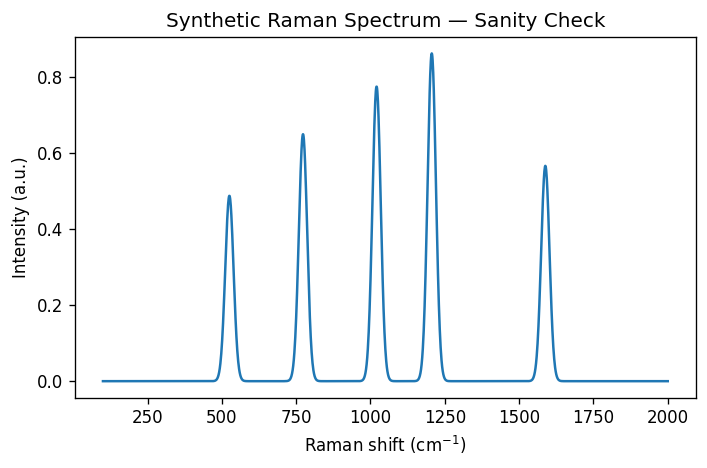

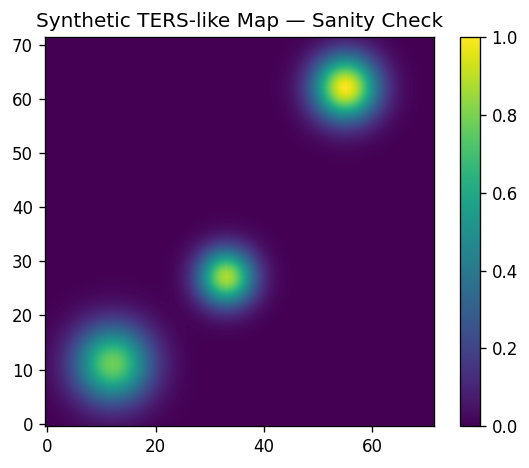

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from src.dataset import demo_vibrational_modes, gaussian_broaden, generate_ters_map
from src.features import spectral_grid
from src.viz import plot_spectrum, plot_ters_map
from pathlib import Path

# Pastikan path figures relatif terhadap project root sekarang
FIG_SPECTRA_DIR = Path("figures/spectra")
FIG_TERS_DIR    = Path("figures/ters_maps")
FIG_SPECTRA_DIR.mkdir(parents=True, exist_ok=True)
FIG_TERS_DIR.mkdir(parents=True, exist_ok=True)

grid = spectral_grid(100, 2000, 1)
freqs, intens = demo_vibrational_modes(seed=7)
spec = gaussian_broaden(freqs, intens, grid, sigma=14.0)

fig, ax = plt.subplots()
plot_spectrum(grid, spec, ax=ax, title="Synthetic Raman Spectrum — Sanity Check")
fig.tight_layout()
out1 = FIG_SPECTRA_DIR / "spectrum_demo.png"
fig.savefig(out1)
print("Saved:", out1.resolve())

img = generate_ters_map(size=72, n_hotspots=3, seed=7)
fig2, ax2 = plt.subplots()
plot_ters_map(img, ax=ax2, title="Synthetic TERS-like Map — Sanity Check")
fig2.tight_layout()
out2 = FIG_TERS_DIR / "ters_map_demo.png"
fig2.savefig(out2)
print("Saved:", out2.resolve())


Cell 12 — (Opsional) Mount Google Drive untuk Persistensi

In [22]:
USE_DRIVE = True  # ubah ke True jika ingin simpan data/checkpoints di Drive

if USE_DRIVE:
    from google.colab import drive
    drive.mount("/content/drive")
    print("Drive mounted. Anda bisa menyalin folder proyek ke /content/drive/MyDrive/")
else:
    print("Skipping Drive mount. Set USE_DRIVE=True untuk mengaktifkan.")


Mounted at /content/drive
Drive mounted. Anda bisa menyalin folder proyek ke /content/drive/MyDrive/


Cell 13 — Ringkasan & Langkah Berikutnya

## ✅ Setup Selesai
- Dependensi utama terpasang (Torch, Lightning, RDKit, timm; PyG opsional).
- Struktur proyek dibuat di `/content/TERS-ML-Portfolio`.
- Stub modul `src/` & `refs/` ditulis.
- Sanity check sukses: tersimpan `figures/spectra/spectrum_demo.png` dan `figures/ters_maps/ters_map_demo.png`.

### ➡️ Next:
1. Buka **`01_data_exploration.ipynb`** → siapkan subset π-conjugated molecules & vibrational modes.
2. Buka **`02_generate_ters_maps.ipynb`** → buat dataset TERS-like (1D & 2D).
3. Training:
   - **`03_train_cnn.ipynb`** (1D spectra, klasifikasi/rekonstruksi),
   - **`04_train_vit.ipynb`** (2D TERS maps, pengenalan struktur).
4. Visualisasi hasil: **`05_results_visualization.ipynb`**.
5. Ringkas & ekspor: **`06_summary_report.ipynb`**.


Cell 1 — Judul & Tujuan

# 01 — Data Exploration (π‑Conjugated Molecules)
**Tujuan:**

1) Menetapkan daftar molekul (benzene, naphthalene, anthracene, graphene nanoflake kecil),

2) Membuat *toy vibrational modes* & **synthetic Raman spectra** per molekul,

3) Visualisasi overlay beberapa contoh & ringkasan statistik dasar,

4) Menyimpan dataset ke `data/` untuk dipakai notebook berikutnya.


Cell 2 — Import & Set Paths

In [23]:
import os, sys, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan project root ada di sys.path dan jadikan CWD
PROJECT_ROOT = Path("/content/TERS-ML-Portfolio")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# Folder penting
DATA_DIR    = PROJECT_ROOT / "data"
FIG_SPEC    = PROJECT_ROOT / "figures" / "spectra"
RESULTS_DIR = PROJECT_ROOT / "results" / "tables"
for p in [DATA_DIR, FIG_SPEC, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CWD:", os.getcwd())
print("Paths OK:", DATA_DIR.exists(), FIG_SPEC.exists(), RESULTS_DIR.exists())


CWD: /content/TERS-ML-Portfolio
Paths OK: True True True


Cell 3 — Reproducibility: Seed

In [24]:
import torch
SEED = 123
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Seed:", SEED)


Seed: 123


Cell 4 — Helper Imports dari src/

In [25]:
from src.dataset import demo_vibrational_modes, gaussian_broaden
from src.features import spectral_grid, normalize_minmax
from src.viz import plot_spectrum


Cell 5 — Definisikan Daftar Molekul (π‑Conjugated Focus)

In [26]:
# Daftar minimal yang relevan dgn TERS & π-conjugated systems
MOLECULES = [
    {"id":"benzene",     "formula":"C6H6"},
    {"id":"naphthalene", "formula":"C10H8"},
    {"id":"anthracene",  "formula":"C14H10"},
    {"id":"pyrene",      "formula":"C16H10"},
    {"id":"coronene",    "formula":"C24H12"},
    {"id":"gnf_small",   "formula":"C24H12 (graphene nanoflake)"},
]

# Simpan daftar untuk keperluan downstream
with open(DATA_DIR / "molecules.json", "w") as f:
    json.dump(MOLECULES, f, indent=2)
MOLECULES


[{'id': 'benzene', 'formula': 'C6H6'},
 {'id': 'naphthalene', 'formula': 'C10H8'},
 {'id': 'anthracene', 'formula': 'C14H10'},
 {'id': 'pyrene', 'formula': 'C16H10'},
 {'id': 'coronene', 'formula': 'C24H12'},
 {'id': 'gnf_small', 'formula': 'C24H12 (graphene nanoflake)'}]

Cell 6 — Parametrik Grid & Generator Raman Sederhana

In [27]:
# Grid Raman & parameter broadening
GRID = spectral_grid(100, 2000, 1)          # 100..2000 cm^-1, step 1
SIGMA = 14.0                                 # Gaussian broadening (cm^-1)

def synthesize_spectrum_for_molecule(mol_id: str, seed: int = 0):
    """
    Menghasilkan (grid, spec, freqs, intens) untuk satu molekul (toy).
    - Menggunakan demo_vibrational_modes(seed) sebagai proxy vibrational lines
    - Sedikit 'shift' berdasarkan kompleksitas molekul
    """
    base_shift = {
        "benzene": 0.0, "naphthalene": 10.0, "anthracene": 18.0,
        "pyrene": 22.0, "coronene": 28.0, "gnf_small": 25.0
    }.get(mol_id, 0.0)

    freqs, intens = demo_vibrational_modes(seed=seed)
    freqs = freqs + base_shift
    spec = gaussian_broaden(freqs, intens, GRID, sigma=SIGMA)
    spec = normalize_minmax(spec)  # skala 0..1 agar stabil untuk ML
    return GRID, spec, freqs, intens


Cell 7 — Bangun Dataset Kecil (Per Molekul Beberapa Sampel)

In [28]:
N_SAMPLES_PER_MOL = 50

records = []
spectra_matrix = []  # [N_total, len(GRID)]
idx = 0

for mol in MOLECULES:
    mol_id = mol["id"]
    for k in range(N_SAMPLES_PER_MOL):
        grid, spec, freqs, intens = synthesize_spectrum_for_molecule(mol_id, seed=SEED + k)
        spectra_matrix.append(spec)
        records.append({
            "index": idx,
            "molecule": mol_id,
            "n_peaks": len(freqs),
            "mean_freq": float(np.mean(freqs)),
            "std_freq": float(np.std(freqs)),
        })
        idx += 1

spectra_matrix = np.stack(spectra_matrix, axis=0)
meta_df = pd.DataFrame.from_records(records)

print("Total samples:", len(records))
print("Spectra shape:", spectra_matrix.shape)
meta_df.head()


Total samples: 300
Spectra shape: (300, 1901)


,index,molecule,n_peaks,mean_freq,std_freq
0,0,benzene,5,1014.329395,371.291092
1,1,benzene,5,1018.011481,370.068890
2,2,benzene,5,1017.026383,378.205413
3,3,benzene,5,1021.007763,374.063060
4,4,benzene,5,1015.581955,370.837325


Cell 8 — Simpan Dataset (NPZ + CSV)

In [29]:
np.savez_compressed(
    DATA_DIR / "toy_ters_raman_spectra.npz",
    grid=GRID, spectra=spectra_matrix, molecules=np.array([r["molecule"] for r in records], dtype=object)
)
meta_df.to_csv(RESULTS_DIR / "eda_meta.csv", index=False)

print("Saved:", DATA_DIR / "toy_ters_raman_spectra.npz")
print("Saved:", RESULTS_DIR / "eda_meta.csv")


Saved: /content/TERS-ML-Portfolio/data/toy_ters_raman_spectra.npz
Saved: /content/TERS-ML-Portfolio/results/tables/eda_meta.csv


Cell 9 — Visualisasi Overlay Spektrum (Sampel Acak per Molekul)

Saved: /content/TERS-ML-Portfolio/figures/spectra/overlay_per_molecule.png


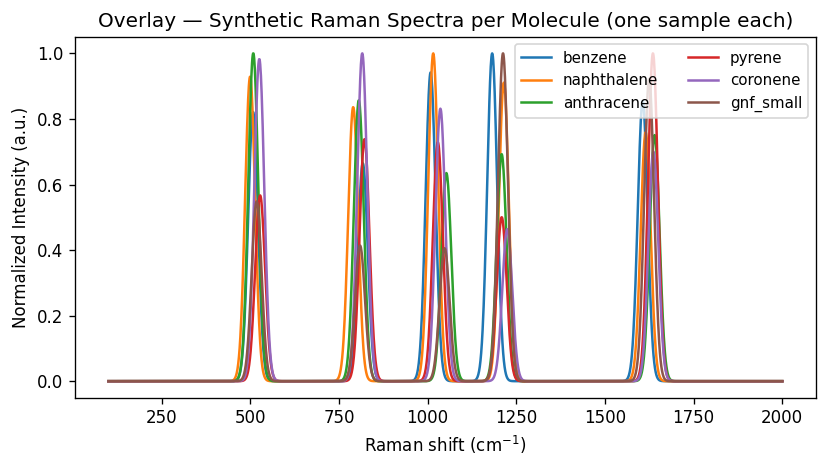

In [30]:
plt.figure(figsize=(7,4))
chosen = []
for mol in MOLECULES:
    mol_id = mol["id"]
    # ambil satu contoh random dari molekul tersebut
    candidates = meta_df.index[meta_df["molecule"]==mol_id].tolist()
    if not candidates:
        continue
    idx = np.random.choice(candidates)
    chosen.append(idx)
    plt.plot(GRID, spectra_matrix[idx], label=mol_id)

plt.xlabel("Raman shift (cm$^{-1}$)")
plt.ylabel("Normalized Intensity (a.u.)")
plt.title("Overlay — Synthetic Raman Spectra per Molecule (one sample each)")
plt.legend(ncol=2, fontsize=9)
plt.tight_layout()

out_path = FIG_SPEC / "overlay_per_molecule.png"
plt.savefig(out_path, dpi=140)
print("Saved:", out_path.resolve())


Cell 10 — Visualisasi Batch (Grid Plot Beberapa Spek)

Saved: /content/TERS-ML-Portfolio/figures/spectra/samples_grid.png


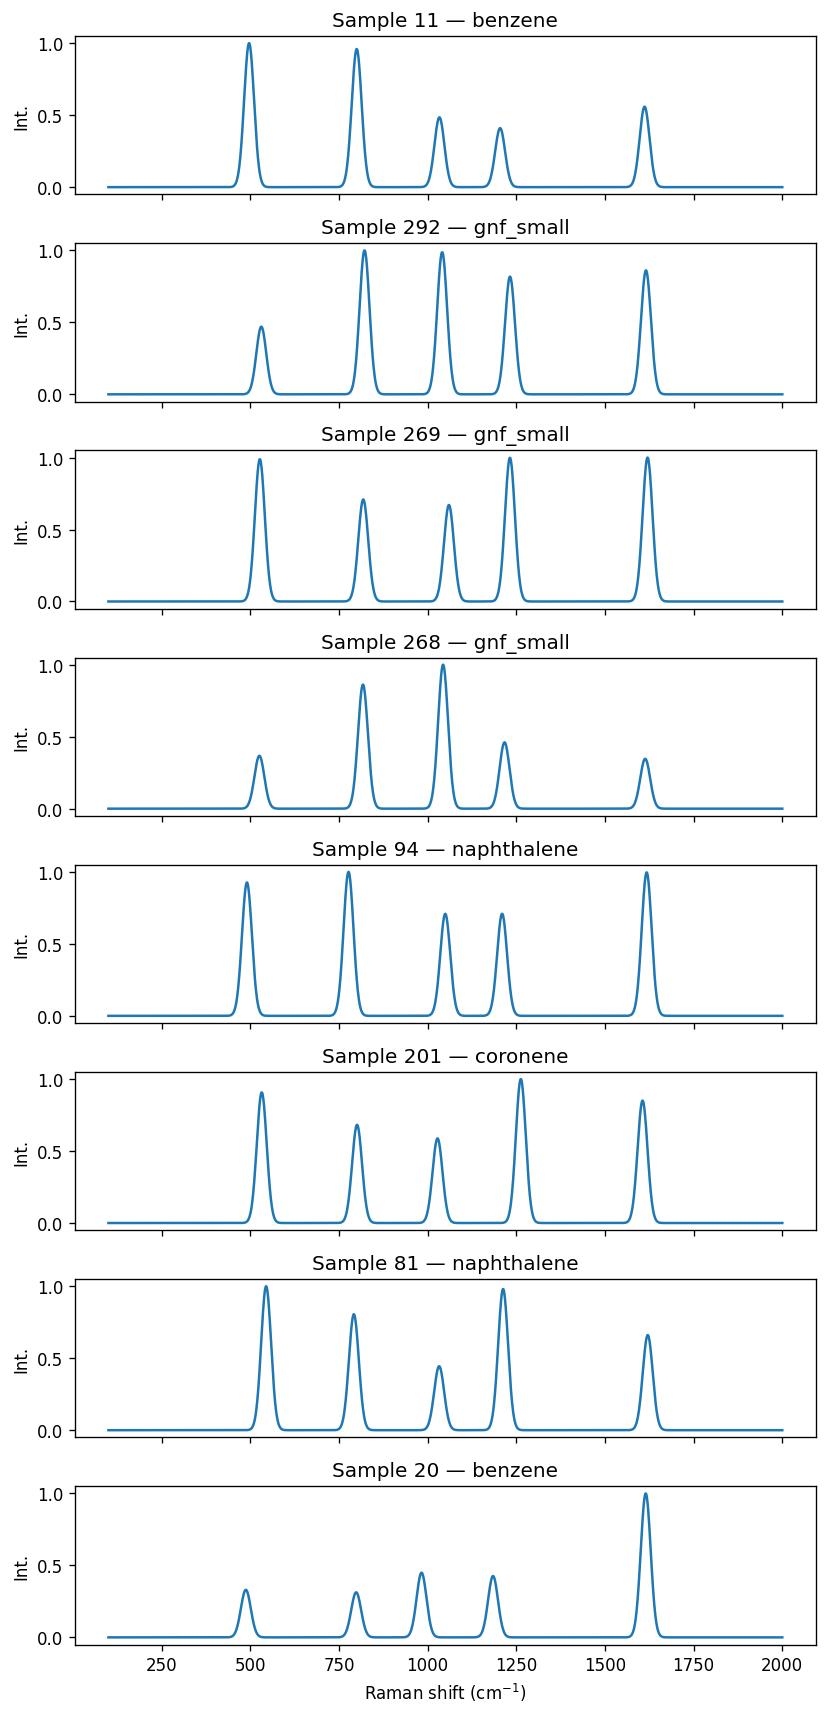

In [31]:
n_show = 8
idxs = np.random.choice(range(spectra_matrix.shape[0]), size=n_show, replace=False)

fig, axes = plt.subplots(n_show, 1, figsize=(7, 1.8*n_show), sharex=True)
for ax, i in zip(axes, idxs):
    y = spectra_matrix[i]
    mol = meta_df.loc[i, "molecule"]
    ax.plot(GRID, y)
    ax.set_ylabel("Int.")
    ax.set_title(f"Sample {i} — {mol}")
axes[-1].set_xlabel("Raman shift (cm$^{-1}$)")
plt.tight_layout()

out_path = FIG_SPEC / "samples_grid.png"
plt.savefig(out_path, dpi=140)
print("Saved:", out_path.resolve())


Cell 11 — Statistik Dasar (Per Molekul)

In [32]:
summary = (
    meta_df
    .groupby("molecule")
    .agg(
        count=("index", "count"),
        peaks_mean=("n_peaks", "mean"),
        freq_mean=("mean_freq", "mean"),
        freq_std=("std_freq", "mean"),
    )
    .reset_index()
    .sort_values("molecule")
)
summary


,molecule,count,peaks_mean,freq_mean,freq_std
0,anthracene,50,5.0,1039.278593,373.635371
1,benzene,50,5.0,1021.278593,373.635371
2,coronene,50,5.0,1049.278593,373.635371
3,gnf_small,50,5.0,1046.278593,373.635371
4,naphthalene,50,5.0,1031.278593,373.635371
5,pyrene,50,5.0,1043.278593,373.635371


Cell 12 — Simpan Tabel Statistik & Tampilkan Bar Chart

Saved: /content/TERS-ML-Portfolio/results/tables/eda_summary_by_molecule.csv
Saved bar: /content/TERS-ML-Portfolio/figures/spectra/bar_samples_per_molecule.png


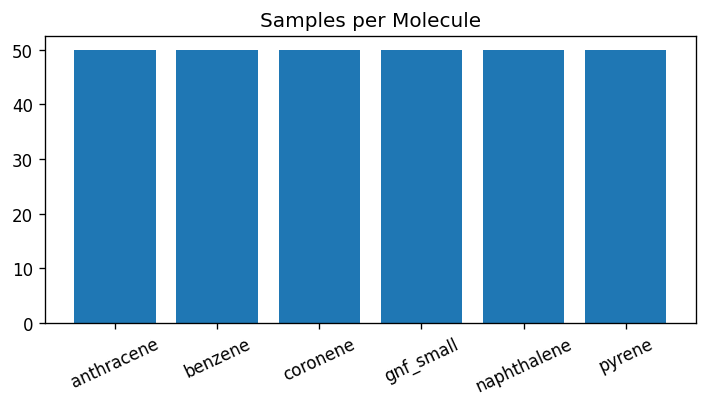

In [33]:
summary_path = RESULTS_DIR / "eda_summary_by_molecule.csv"
summary.to_csv(summary_path, index=False)
print("Saved:", summary_path.resolve())

# Bar chart jumlah sampel per molekul
plt.figure(figsize=(6,3.5))
plt.bar(summary["molecule"], summary["count"])
plt.title("Samples per Molecule")
plt.xticks(rotation=25)
plt.tight_layout()
plt.savefig(FIG_SPEC / "bar_samples_per_molecule.png", dpi=140)
print("Saved bar:", (FIG_SPEC / "bar_samples_per_molecule.png").resolve())


Cell 13 — Sanity Check: Distribusi Frekuensi Mean (Histogram)

Saved hist: /content/TERS-ML-Portfolio/figures/spectra/hist_mean_frequency.png


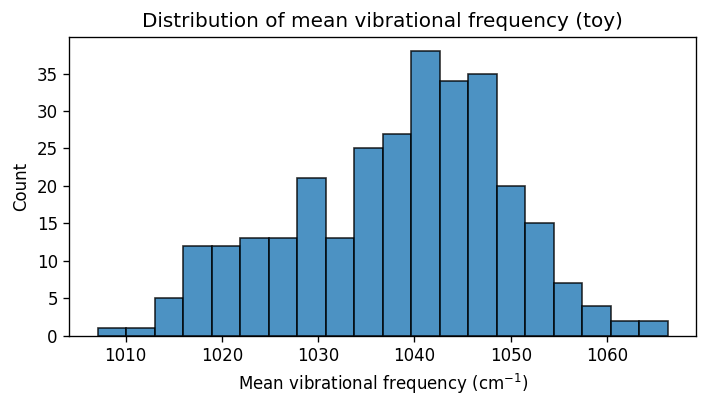

In [34]:
plt.figure(figsize=(6,3.5))
plt.hist(meta_df["mean_freq"], bins=20, edgecolor="k", alpha=0.8)
plt.xlabel("Mean vibrational frequency (cm$^{-1}$)")
plt.ylabel("Count")
plt.title("Distribution of mean vibrational frequency (toy)")
plt.tight_layout()
plt.savefig(FIG_SPEC / "hist_mean_frequency.png", dpi=140)
print("Saved hist:", (FIG_SPEC / "hist_mean_frequency.png").resolve())


Cell 14 — Ringkasan & Next Steps

## ✅ EDA Selesai
- Dataset *toy* synthetic Raman untuk π‑conjugated molecules berhasil dibuat.
- File tersimpan:
  - `data/toy_ters_raman_spectra.npz` (grid, spectra, labels)
  - `results/tables/eda_meta.csv` (metadata per sampel)
  - `results/tables/eda_summary_by_molecule.csv` (statistik ringkas)
  - `figures/spectra/*.png` (overlay, grid, bar, histogram)

### ➡️ Next:
1. Buka **`02_generate_ters_maps.ipynb`** → buat **TERS maps (2D)** dengan hotspot/spatial modulation.
2. Lanjut **`03_train_cnn.ipynb`** untuk klasifikasi 1D spectra.
3. (Opsional) siapkan split train/val/test & seed fix untuk reprodusibilitas eksperimen.


Cell 15 — (Markdown) Tujuan Split

## Split: Train / Val / Test (Stratified)
**Tujuan:**
- Membuat split **70/15/15** secara **stratified** berdasarkan label `molecule`.
- Menyimpan **indeks** tiap split (CSV/JSON) untuk reprodusibilitas.
- Menyimpan **file NPZ per split** (grid, spectra, labels) untuk training berikutnya.


Cell 16 — Siapkan Label & Stratified Split

In [35]:
from sklearn.model_selection import StratifiedShuffleSplit
import json

# Label per sample (panjang = spectra_matrix.shape[0])
labels = np.array([r["molecule"] for r in records])
unique_labels, counts = np.unique(labels, return_counts=True)
print("Class balance:", dict(zip(unique_labels, counts)))

# Parameter split
SEED_SPLIT = 2025
train_ratio, val_ratio, test_ratio = 0.70, 0.15, 0.15
assert abs(train_ratio + val_ratio + test_ratio - 1.0) < 1e-9

# --- Stratified: train vs temp (val+test)
sss1 = StratifiedShuffleSplit(n_splits=1, test_size=1.0 - train_ratio, random_state=SEED_SPLIT)
(train_idx, temp_idx) = next(sss1.split(np.zeros_like(labels), labels))  # fitur dummy, hanya pakai labels

# --- Stratified: val vs test dari temp
temp_labels = labels[temp_idx]
val_size_in_temp = val_ratio / (val_ratio + test_ratio)  # 0.5 untuk 15/15
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=1.0 - val_size_in_temp, random_state=SEED_SPLIT)
(val_rel_idx, test_rel_idx) = next(sss2.split(np.zeros_like(temp_labels), temp_labels))

val_idx = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

len(train_idx), len(val_idx), len(test_idx)


Class balance: {np.str_('anthracene'): np.int64(50), np.str_('benzene'): np.int64(50), np.str_('coronene'): np.int64(50), np.str_('gnf_small'): np.int64(50), np.str_('naphthalene'): np.int64(50), np.str_('pyrene'): np.int64(50)}


(209, 45, 46)

Cell 17 — Validasi Distribusi & Simpan Indeks Split

In [36]:
def count_by_split(idxs, name):
    labs = labels[idxs]
    u, c = np.unique(labs, return_counts=True)
    print(f"[{name}] total={len(idxs)} ::", dict(zip(u, c)))

count_by_split(train_idx, "train")
count_by_split(val_idx,   "val")
count_by_split(test_idx,  "test")

# Simpan indeks split (CSV & JSON)
split_df = pd.DataFrame({
    "index": np.concatenate([train_idx, val_idx, test_idx]),
    "split": (["train"]*len(train_idx)) + (["val"]*len(val_idx)) + (["test"]*len(test_idx)),
    "molecule": labels[np.concatenate([train_idx, val_idx, test_idx])]
}).sort_values("index").reset_index(drop=True)

split_csv = RESULTS_DIR / "split_indices.csv"
split_json = RESULTS_DIR / "split_indices.json"
split_df.to_csv(split_csv, index=False)
with open(split_json, "w") as f:
    json.dump({
        "seed": SEED_SPLIT,
        "ratios": {"train": train_ratio, "val": val_ratio, "test": test_ratio},
        "train_idx": train_idx.tolist(),
        "val_idx": val_idx.tolist(),
        "test_idx": test_idx.tolist(),
    }, f, indent=2)

print("Saved:", split_csv.resolve())
print("Saved:", split_json.resolve())
split_df.head()


[train] total=209 :: {np.str_('anthracene'): np.int64(35), np.str_('benzene'): np.int64(35), np.str_('coronene'): np.int64(34), np.str_('gnf_small'): np.int64(35), np.str_('naphthalene'): np.int64(35), np.str_('pyrene'): np.int64(35)}
[val] total=45 :: {np.str_('anthracene'): np.int64(7), np.str_('benzene'): np.int64(8), np.str_('coronene'): np.int64(8), np.str_('gnf_small'): np.int64(7), np.str_('naphthalene'): np.int64(8), np.str_('pyrene'): np.int64(7)}
[test] total=46 :: {np.str_('anthracene'): np.int64(8), np.str_('benzene'): np.int64(7), np.str_('coronene'): np.int64(8), np.str_('gnf_small'): np.int64(8), np.str_('naphthalene'): np.int64(7), np.str_('pyrene'): np.int64(8)}
Saved: /content/TERS-ML-Portfolio/results/tables/split_indices.csv
Saved: /content/TERS-ML-Portfolio/results/tables/split_indices.json


,index,split,molecule
0,0,train,benzene
1,1,train,benzene
2,2,train,benzene
3,3,train,benzene
4,4,train,benzene


Cell 18 — Simpan NPZ per Split (Untuk Training)

In [37]:
# Helper untuk simpan paket split (grid sama untuk semua)
def save_split_npz(name, idxs):
    out_path = DATA_DIR / f"spectra_{name}.npz"
    np.savez_compressed(
        out_path,
        grid=GRID,                                  # (L,)
        spectra=spectra_matrix[idxs],               # (N_split, L)
        labels=labels[idxs],                        # (N_split,)
    )
    print("Saved:", out_path.resolve())

save_split_npz("train", train_idx)
save_split_npz("val",   val_idx)
save_split_npz("test",  test_idx)


Saved: /content/TERS-ML-Portfolio/data/spectra_train.npz
Saved: /content/TERS-ML-Portfolio/data/spectra_val.npz
Saved: /content/TERS-ML-Portfolio/data/spectra_test.npz


Cell 19 — Cek Cepat: Visualisasi Distribusi per Split

Saved: /content/TERS-ML-Portfolio/figures/spectra/split_distribution.png


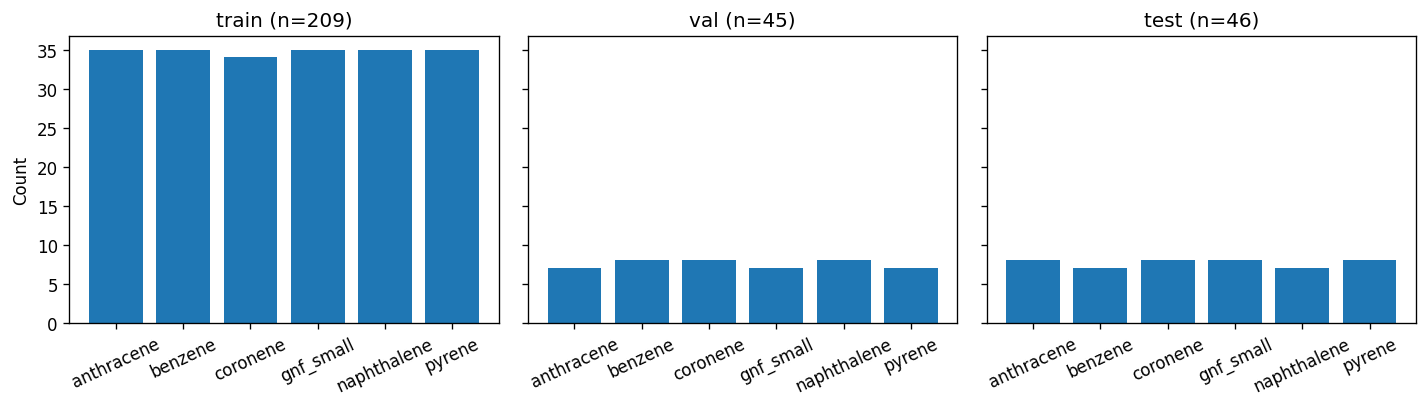

In [38]:
# Bar chart per split per class (cepat untuk sanity check)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, (name, idxs) in zip(axes, [("train", train_idx), ("val", val_idx), ("test", test_idx)]):
    labs = labels[idxs]
    u, c = np.unique(labs, return_counts=True)
    ax.bar(u, c)
    ax.set_title(f"{name} (n={len(idxs)})")
    ax.tick_params(axis='x', rotation=25)
axes[0].set_ylabel("Count")
plt.tight_layout()
out_path = FIG_SPEC / "split_distribution.png"
plt.savefig(out_path, dpi=140)
print("Saved:", out_path.resolve())


Cell 20 — Ringkasan Split & Next Steps
## ✅ Split Selesai (Stratified 70/15/15)
Artifacts tersimpan:
- **Indeks split**:  
  - `results/tables/split_indices.csv`  
  - `results/tables/split_indices.json` (termasuk seed & rasio)  
- **Paket data per split**:  
  - `data/spectra_train.npz`, `data/spectra_val.npz`, `data/spectra_test.npz`  
- **Visual sanity check**:  
  - `figures/spectra/split_distribution.png`

### ➡️ Next:
- Gunakan `data/spectra_train.npz` & `data/spectra_val.npz` di **`03_train_cnn.ipynb`** (klasifikasi 1D spectra).
- (Opsional) Tambahkan stratifikasi yang sama untuk **TERS maps (2D)** di `02_generate_ters_maps.ipynb`.


Cell 1 — Judul & Tujuan

# 02 — Generate TERS Maps (2D)
**Tujuan:**

1) Membuat **TERS-like maps** (citra 2D) per molekul π‑conjugated,

2) Menambahkan **noise & augmentasi** ringan agar realistis,

3) Menyimpan dataset (`.npz`) + metadata (`.csv`),

4) Melakukan **train/val/test split** (stratified),

5) Visual sanity check (montase contoh & distribusi kelas).


Cell 2 — Import & Set Paths

In [39]:
import os, sys, json, random
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan project root ada di sys.path dan jadikan CWD
PROJECT_ROOT = Path("/content/TERS-ML-Portfolio")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

DATA_DIR    = PROJECT_ROOT / "data"
FIG_DIR     = PROJECT_ROOT / "figures" / "ters_maps"
RESULTS_DIR = PROJECT_ROOT / "results" / "tables"
for p in [DATA_DIR, FIG_DIR, RESULTS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CWD:", os.getcwd())
print("Dirs OK:", DATA_DIR.exists(), FIG_DIR.exists(), RESULTS_DIR.exists())


CWD: /content/TERS-ML-Portfolio
Dirs OK: True True True


Cell 3 — Reproducibility: Seed

In [40]:
import torch
SEED = 2025
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
print("Seed:", SEED)


Seed: 2025


Cell 4 — Helper Imports dari src/ & Load Molecules

In [41]:
from src.dataset import generate_ters_map
from src.features import normalize_minmax  # dipakai jika perlu normalisasi
from src.viz import plot_ters_map

# Ambil daftar molekul dari 01_data_exploration (jika ada)
mol_json = DATA_DIR / "molecules.json"
if mol_json.exists():
    with open(mol_json, "r") as f:
        MOLECULES = json.load(f)
else:
    # fallback kecil bila file belum ada
    MOLECULES = [
        {"id":"benzene",     "formula":"C6H6"},
        {"id":"naphthalene", "formula":"C10H8"},
        {"id":"anthracene",  "formula":"C14H10"},
        {"id":"pyrene",      "formula":"C16H10"},
        {"id":"coronene",    "formula":"C24H12"},
        {"id":"gnf_small",   "formula":"C24H12 (graphene nanoflake)"},
    ]
MOLECULES


[{'id': 'benzene', 'formula': 'C6H6'},
 {'id': 'naphthalene', 'formula': 'C10H8'},
 {'id': 'anthracene', 'formula': 'C14H10'},
 {'id': 'pyrene', 'formula': 'C16H10'},
 {'id': 'coronene', 'formula': 'C24H12'},
 {'id': 'gnf_small', 'formula': 'C24H12 (graphene nanoflake)'}]

Cell 5 — Konfigurasi Generator TERS Map + Augmentasi

In [42]:
# Ukuran peta & jumlah sampel
IMG_SIZE = 96
N_SAMPLES_PER_MOL = 60  # bisa disesuaikan

# Konfigurasi per-molekul → kontrol "tekstur" TERS (jumlah hotspot, skala, noise)
MOLECULE_PARAMS = {
    "benzene":     {"n_hotspots": (2, 3), "sigma": (2.5, 3.5), "amp": (0.65, 1.00), "bg": (0.00, 0.05)},
    "naphthalene": {"n_hotspots": (3, 4), "sigma": (2.5, 4.0), "amp": (0.60, 0.95), "bg": (0.00, 0.06)},
    "anthracene":  {"n_hotspots": (3, 5), "sigma": (2.0, 4.5), "amp": (0.55, 0.95), "bg": (0.00, 0.07)},
    "pyrene":      {"n_hotspots": (4, 6), "sigma": (2.0, 4.0), "amp": (0.55, 0.90), "bg": (0.00, 0.08)},
    "coronene":    {"n_hotspots": (4, 7), "sigma": (1.8, 3.8), "amp": (0.50, 0.90), "bg": (0.00, 0.10)},
    "gnf_small":   {"n_hotspots": (3, 5), "sigma": (2.0, 4.0), "amp": (0.55, 0.92), "bg": (0.00, 0.07)},
}

def rnd_between(lo, hi, rng):
    return lo + (hi - lo) * rng.rand()

def add_noise_and_aug(img, rng, p_flip=0.5, p_rot=0.5, noise_std=(0.00, 0.03), blur_sigma=(0.0, 0.8)):
    x = img.copy()
    # Gaussian noise
    ns = rnd_between(*noise_std, rng)
    if ns > 1e-6:
        x = x + rng.normal(0, ns, size=x.shape)
    # Clip & normalize 0..1
    x = x - x.min()
    if x.max() > 0:
        x = x / x.max()
    # Random flips
    if rng.rand() < p_flip:
        x = np.flip(x, axis=0).copy()
    if rng.rand() < p_flip:
        x = np.flip(x, axis=1).copy()
    # Random 90-deg rotation
    if rng.rand() < p_rot:
        k = rng.randint(0, 4)
        x = np.rot90(x, k).copy()
    # Optional mild Gaussian blur via convolution (manual)
    bs = rnd_between(*blur_sigma, rng)
    if bs > 0.05:
        # discrete approx: separable 1D gaussian kernel
        rad = int(3*bs)
        ax = np.arange(-rad, rad+1)
        kernel = np.exp(-0.5 * (ax/bs)**2)
        kernel /= kernel.sum()
        # convolve rows then cols
        x = np.apply_along_axis(lambda v: np.convolve(v, kernel, mode="same"), axis=0, arr=x)
        x = np.apply_along_axis(lambda v: np.convolve(v, kernel, mode="same"), axis=1, arr=x)
        x = np.clip(x, 0, 1)
    return x

def generate_ters_map_for_molecule(mol_id: str, seed: int):
    """
    Buat TERS-like map dgn parameter tergantung molekul:
    - pilih jumlah hotspot, sigma, amplitude range, background
    - panggil generate_ters_map() berulang & gabungkan
    """
    cfg = MOLECULE_PARAMS.get(mol_id, MOLECULE_PARAMS["benzene"])
    rng = np.random.RandomState(seed)
    n_hot = rng.randint(cfg["n_hotspots"][0], cfg["n_hotspots"][1] + 1)
    base = np.zeros((IMG_SIZE, IMG_SIZE), dtype=float)

    # gabungkan beberapa peta hotspot dengan parameter sedikit diacak
    for _ in range(n_hot):
        # generate_ters_map dari src.dataset menghasilkan peta normalisasi 0..1
        local = generate_ters_map(size=IMG_SIZE,
                                  n_hotspots=rng.randint(1, 3),
                                  seed=int(rng.randint(1e9)))
        # scale oleh amplitude
        amp = rnd_between(*cfg["amp"], rng)
        base += amp * local

    # tambah "background" lemah
    bg = rnd_between(*cfg["bg"], rng)
    if bg > 0:
        base += bg * rng.rand(IMG_SIZE, IMG_SIZE)

    # normalisasi awal
    base = base - base.min()
    if base.max() > 0:
        base = base / base.max()

    # augmentasi & noise
    base = add_noise_and_aug(base, rng)
    return np.clip(base, 0.0, 1.0)


Cell 6 — Generate Dataset (Images + Metadata)

In [43]:
records = []
images = []
idx = 0

for mol in MOLECULES:
    mol_id = mol["id"]
    for k in range(N_SAMPLES_PER_MOL):
        seed = SEED + hash((mol_id, k)) % 10_000_000
        img = generate_ters_map_for_molecule(mol_id, seed=seed)
        images.append(img)
        records.append({
            "index": idx,
            "molecule": mol_id,
            "seed": int(seed),
        })
        idx += 1

images = np.stack(images, axis=0)            # (N, H, W)
meta_df = pd.DataFrame.from_records(records) # (N, cols)
print("Images:", images.shape)
meta_df.head()


Images: (360, 96, 96)


,index,molecule,seed
0,0,benzene,4967789
1,1,benzene,7903295
2,2,benzene,9901720
3,3,benzene,7205354
4,4,benzene,9203779


Cell 7 — Simpan Dataset (NPZ + CSV)

In [44]:
labels = meta_df["molecule"].values.astype(object)

np.savez_compressed(
    DATA_DIR / "ters_maps_full.npz",
    images=images,               # float32 [0..1]
    labels=labels,               # object array of str
)
meta_df.to_csv(RESULTS_DIR / "ters_maps_meta.csv", index=False)

print("Saved:", (DATA_DIR / "ters_maps_full.npz").resolve())
print("Saved:", (RESULTS_DIR / "ters_maps_meta.csv").resolve())


Saved: /content/TERS-ML-Portfolio/data/ters_maps_full.npz
Saved: /content/TERS-ML-Portfolio/results/tables/ters_maps_meta.csv


Cell 8 — Visualisasi: Satu Contoh per Molekul

Saved: /content/TERS-ML-Portfolio/figures/ters_maps/samples_per_molecule.png


<Figure size 1200x720 with 0 Axes>

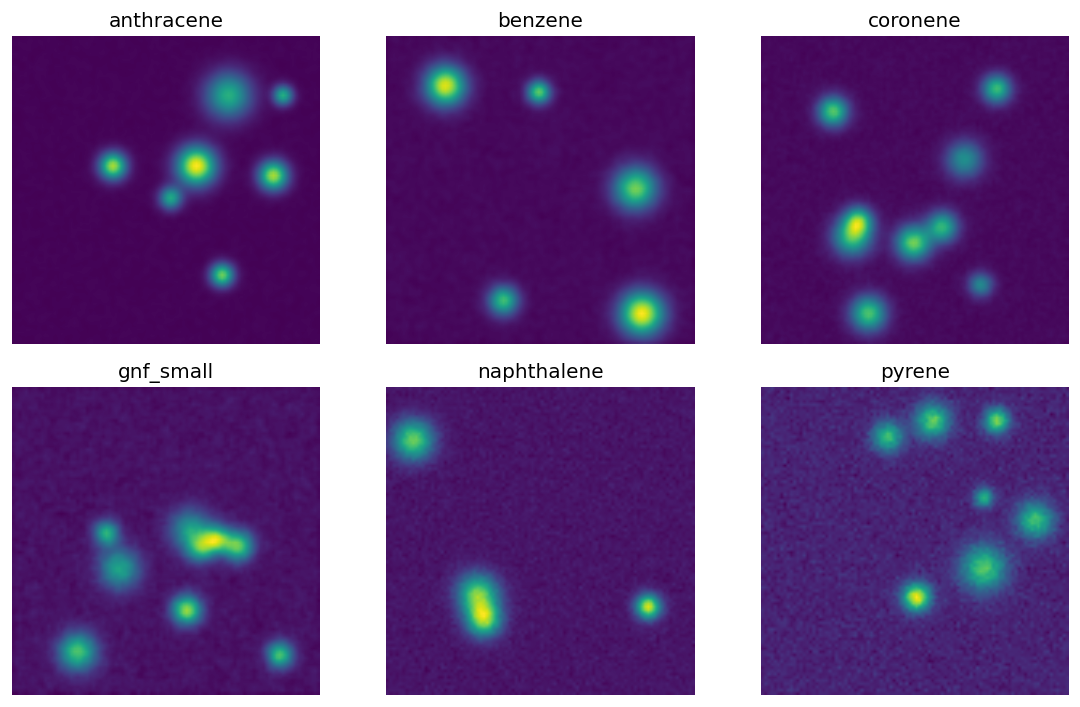

In [45]:
plt.figure(figsize=(10, 6))
uniq = sorted(meta_df["molecule"].unique())
ncols = 3
nrows = int(np.ceil(len(uniq)/ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(3.2*ncols, 3.0*nrows))
axes = axes.ravel()

for ax, mol_id in zip(axes, uniq):
    i = meta_df.index[meta_df["molecule"]==mol_id][0]
    ax.imshow(images[i], origin="lower", interpolation="bilinear")
    ax.set_title(mol_id)
    ax.axis("off")

for ax in axes[len(uniq):]:
    ax.axis("off")

plt.tight_layout()
out_path = FIG_DIR / "samples_per_molecule.png"
plt.savefig(out_path, dpi=140)
print("Saved:", out_path.resolve())


Cell 9 — Statistik Dasar Intensitas per Molekul

In [46]:
rows = []
for mol_id in sorted(meta_df["molecule"].unique()):
    idxs = meta_df.index[meta_df["molecule"]==mol_id].values
    sub = images[idxs]
    rows.append({
        "molecule": mol_id,
        "count": len(idxs),
        "mean_intensity": float(sub.mean()),
        "std_intensity": float(sub.std()),
        "p99_intensity": float(np.quantile(sub, 0.99)),
    })
stats_df = pd.DataFrame(rows).sort_values("molecule")
stats_df

stats_path = RESULTS_DIR / "ters_maps_stats.csv"
stats_df.to_csv(stats_path, index=False)
print("Saved:", stats_path.resolve())


Saved: /content/TERS-ML-Portfolio/results/tables/ters_maps_stats.csv


Cell 10 — Stratified Split (Train/Val/Test 70/15/15)

In [47]:
from sklearn.model_selection import StratifiedShuffleSplit
import json

labels = meta_df["molecule"].values
SEED_SPLIT = 2025
train_ratio, val_ratio, test_ratio = 0.70, 0.15, 0.15

sss1 = StratifiedShuffleSplit(n_splits=1, test_size=1.0 - train_ratio, random_state=SEED_SPLIT)
(train_idx, temp_idx) = next(sss1.split(np.zeros_like(labels), labels))

temp_labels = labels[temp_idx]
val_size_in_temp = val_ratio / (val_ratio + test_ratio)  # 0.5
sss2 = StratifiedShuffleSplit(n_splits=1, test_size=1.0 - val_size_in_temp, random_state=SEED_SPLIT)
(val_rel_idx, test_rel_idx) = next(sss2.split(np.zeros_like(temp_labels), temp_labels))
val_idx  = temp_idx[val_rel_idx]
test_idx = temp_idx[test_rel_idx]

def count_by_split(idxs, name):
    labs = labels[idxs]
    u, c = np.unique(labs, return_counts=True)
    print(f"[{name}] n={len(idxs)} ::", dict(zip(u, c)))

count_by_split(train_idx, "train")
count_by_split(val_idx,   "val")
count_by_split(test_idx,  "test")

# Simpan indeks split
split_df = pd.DataFrame({
    "index": np.concatenate([train_idx, val_idx, test_idx]),
    "split": (["train"]*len(train_idx)) + (["val"]*len(val_idx)) + (["test"]*len(test_idx)),
    "molecule": labels[np.concatenate([train_idx, val_idx, test_idx])]
}).sort_values("index").reset_index(drop=True)

split_csv = RESULTS_DIR / "ters_maps_split_indices.csv"
split_json = RESULTS_DIR / "ters_maps_split_indices.json"
split_df.to_csv(split_csv, index=False)
with open(split_json, "w") as f:
    json.dump({
        "seed": SEED_SPLIT,
        "ratios": {"train": train_ratio, "val": val_ratio, "test": test_ratio},
        "train_idx": train_idx.tolist(),
        "val_idx": val_idx.tolist(),
        "test_idx": test_idx.tolist(),
    }, f, indent=2)

print("Saved:", split_csv.resolve())
print("Saved:", split_json.resolve())
split_df.head()


[train] n=251 :: {'anthracene': np.int64(42), 'benzene': np.int64(42), 'coronene': np.int64(41), 'gnf_small': np.int64(42), 'naphthalene': np.int64(42), 'pyrene': np.int64(42)}
[val] n=54 :: {'anthracene': np.int64(9), 'benzene': np.int64(9), 'coronene': np.int64(9), 'gnf_small': np.int64(9), 'naphthalene': np.int64(9), 'pyrene': np.int64(9)}
[test] n=55 :: {'anthracene': np.int64(9), 'benzene': np.int64(9), 'coronene': np.int64(10), 'gnf_small': np.int64(9), 'naphthalene': np.int64(9), 'pyrene': np.int64(9)}
Saved: /content/TERS-ML-Portfolio/results/tables/ters_maps_split_indices.csv
Saved: /content/TERS-ML-Portfolio/results/tables/ters_maps_split_indices.json


,index,split,molecule
0,0,val,benzene
1,1,train,benzene
2,2,train,benzene
3,3,test,benzene
4,4,val,benzene


Cell 11 — Simpan NPZ per Split (Untuk Training ViT/ResNet)

In [48]:
def save_split_npz(name, idxs, arr=images, labs=labels):
    out_path = DATA_DIR / f"ters_maps_{name}.npz"
    np.savez_compressed(
        out_path,
        images=arr[idxs].astype(np.float32),   # (N, H, W)
        labels=labs[idxs],                     # (N,)
    )
    print("Saved:", out_path.resolve())

save_split_npz("train", train_idx)
save_split_npz("val",   val_idx)
save_split_npz("test",  test_idx)


Saved: /content/TERS-ML-Portfolio/data/ters_maps_train.npz
Saved: /content/TERS-ML-Portfolio/data/ters_maps_val.npz
Saved: /content/TERS-ML-Portfolio/data/ters_maps_test.npz


Cell 12 — Visualisasi Distribusi Kelas per Split + Montase Train

Saved: /content/TERS-ML-Portfolio/figures/ters_maps/split_distribution.png
Saved: /content/TERS-ML-Portfolio/figures/ters_maps/train_montage.png


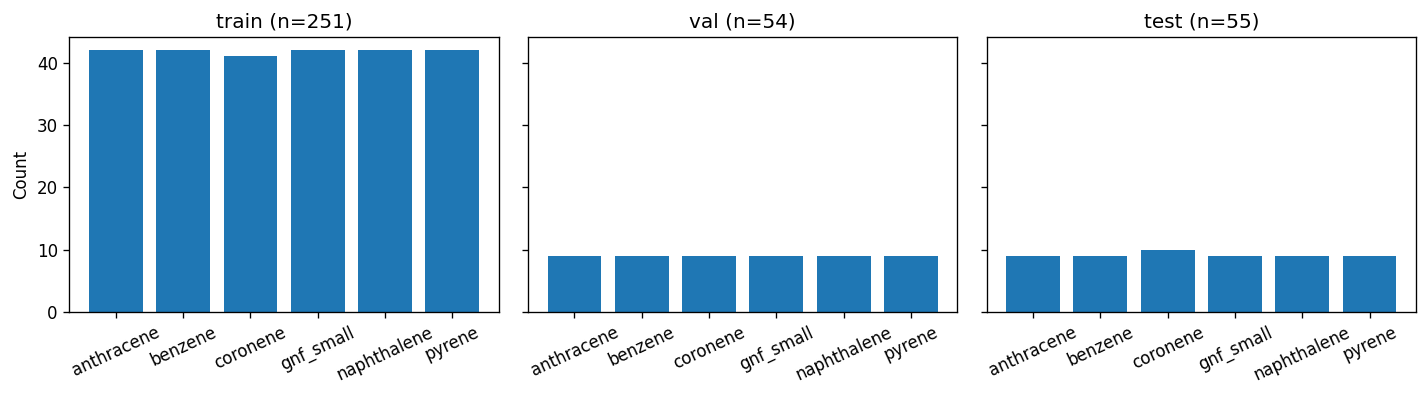

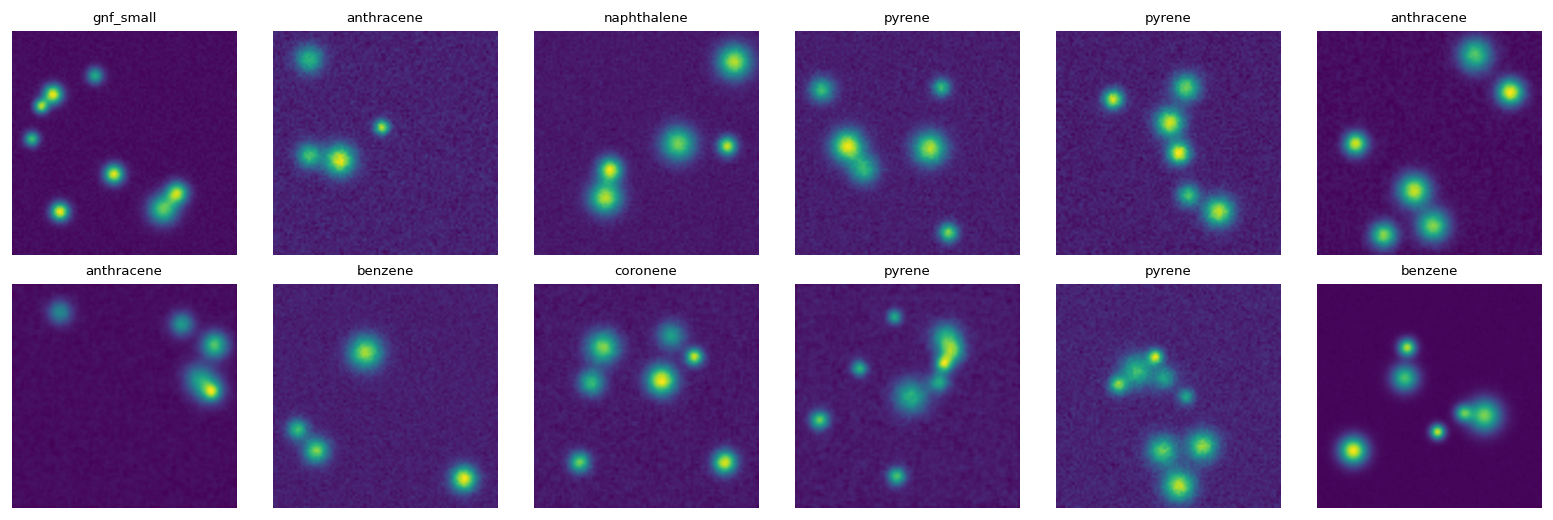

In [49]:
# Bar distribusi kelas per split
fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), sharey=True)
for ax, (name, idxs) in zip(axes, [("train", train_idx), ("val", val_idx), ("test", test_idx)]):
    labs = labels[idxs]
    u, c = np.unique(labs, return_counts=True)
    ax.bar(u, c)
    ax.set_title(f"{name} (n={len(idxs)})")
    ax.tick_params(axis='x', rotation=25)
axes[0].set_ylabel("Count")
plt.tight_layout()
bar_path = FIG_DIR / "split_distribution.png"
plt.savefig(bar_path, dpi=140)
print("Saved:", bar_path.resolve())

# Montase contoh dari train
n_show = 12
sel = np.random.choice(train_idx, size=min(n_show, len(train_idx)), replace=False)
cols = 6
rows = int(np.ceil(len(sel)/cols))

fig2, axes2 = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
axes2 = axes2.ravel()
for ax, i in zip(axes2, sel):
    ax.imshow(images[i], origin="lower", interpolation="bilinear")
    ax.set_title(meta_df.loc[i, "molecule"], fontsize=8)
    ax.axis("off")
for ax in axes2[len(sel):]:
    ax.axis("off")
plt.tight_layout()
mont_path = FIG_DIR / "train_montage.png"
plt.savefig(mont_path, dpi=140)
print("Saved:", mont_path.resolve())


Cell 13 — Ringkasan & Next Steps

## ✅ TERS Maps Selesai
Artifacts:
- Dataset penuh: `data/ters_maps_full.npz`
- Metadata: `results/tables/ters_maps_meta.csv`
- Statistik: `results/tables/ters_maps_stats.csv`
- Split (indeks): `results/tables/ters_maps_split_indices.csv` / `.json`
- Paket split: `data/ters_maps_train.npz`, `val.npz`, `test.npz`
- Gambar: `figures/ters_maps/samples_per_molecule.png`, `split_distribution.png`, `train_montage.png`

### ➡️ Next:
- Latih model 2D (ViT/ResNet) di **`04_train_vit.ipynb`**.
- Untuk 1D spectra, lanjutkan **`03_train_cnn.ipynb`**.
- (Opsional) Sinkronkan rasio split dengan 01_* jika ingin konsistensi lintas modality.


Cell 1 — Judul & Tujuan

# 03 — Train CNN (1D) on Raman Spectra
**Tujuan:**

1) Memuat dataset split (`spectra_train/val/test.npz`) dan *label encoding*,

2) Membangun `Dataset` + `DataLoader` dengan augmentasi ringan untuk 1D spectra,

3) Melatih **CNN 1D** (Cross-Entropy, class weights, AMP jika GPU),

4) Menyimpan **checkpoint terbaik**, kurva training, dan metrik (CSV/JSON),

5) Evaluasi pada **test set** (accuracy, macro-F1, confusion matrix).


Cell 2 — Import & Set Paths

In [61]:
import os, sys, json, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler

# Pastikan project root
PROJECT_ROOT = Path("/content/TERS-ML-Portfolio")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# Direktori
DATA_DIR   = PROJECT_ROOT / "data"
FIG_CURVE  = PROJECT_ROOT / "figures" / "curves"
FIG_CM     = PROJECT_ROOT / "figures" / "confusion_matrices"
CKPT_DIR   = PROJECT_ROOT / "results" / "checkpoints"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"

for p in [FIG_CURVE, FIG_CM, CKPT_DIR, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CWD:", os.getcwd())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CWD: /content/TERS-ML-Portfolio
GPU: Tesla T4


Cell 3 — Seed & Device

In [62]:
SEED = 2025
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()  # pakai mixed precision kalau ada GPU
print("Seed:", SEED, "| Device:", DEVICE, "| AMP:", USE_AMP)

# Style plot
import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 120
mpl.rcParams["figure.figsize"] = (6,4)


Seed: 2025 | Device: cuda | AMP: True


Cell 4 — Muat Data Split & Label Encoding

In [63]:
# File NPZ dari 01_data_exploration.ipynb
train_npz = np.load(DATA_DIR / "spectra_train.npz", allow_pickle=True)
val_npz   = np.load(DATA_DIR / "spectra_val.npz", allow_pickle=True)
test_npz  = np.load(DATA_DIR / "spectra_test.npz", allow_pickle=True)

GRID_train   = train_npz["grid"]         # (L,)
SPECT_train  = train_npz["spectra"]      # (N_train, L)
LABELS_train = train_npz["labels"]       # (N_train,)

GRID_val   = val_npz["grid"]
SPECT_val  = val_npz["spectra"]
LABELS_val = val_npz["labels"]

GRID_test   = test_npz["grid"]
SPECT_test  = test_npz["spectra"]
LABELS_test = test_npz["labels"]

# Konsistensi grid
assert np.allclose(GRID_train, GRID_val) and np.allclose(GRID_train, GRID_test), "GRID mismatch across splits!"

# Label encoder (fit di train)
le = LabelEncoder()
y_train = le.fit_transform(LABELS_train)
y_val   = le.transform(LABELS_val)
y_test  = le.transform(LABELS_test)

CLASS_NAMES = list(le.classes_)
N_CLASSES = len(CLASS_NAMES)
print("Classes:", CLASS_NAMES)
print("Shapes:", SPECT_train.shape, SPECT_val.shape, SPECT_test.shape, "| L =", GRID_train.shape[0])


Classes: [np.str_('anthracene'), np.str_('benzene'), np.str_('coronene'), np.str_('gnf_small'), np.str_('naphthalene'), np.str_('pyrene')]
Shapes: (209, 1901) (45, 1901) (46, 1901) | L = 1901


In [64]:
# Force float32 to avoid upcasting later
SPECT_train = SPECT_train.astype(np.float32, copy=False)
SPECT_val   = SPECT_val.astype(np.float32, copy=False)
SPECT_test  = SPECT_test.astype(np.float32, copy=False)


Cell 5 — Dataset & Augmentasi 1D

In [65]:
def augment_spectrum_1d(x, rng, p_noise=0.5, p_shift=0.5, noise_std=(0.0, 0.02), max_shift=6):
    """
    Augmentasi ringan tanpa mengubah dtype ke float64.
    """
    y = x.astype(np.float32, copy=True)  # pastikan float32
    # noise
    if rng.rand() < p_noise:
        std = float(rng.uniform(*noise_std))
        if std > 1e-6:
            noise = rng.normal(0.0, std, size=y.shape).astype(np.float32)
            y = np.clip(y + noise, 0.0, 1.0)
    # shift
    if rng.rand() < p_shift:
        s = int(rng.randint(-max_shift, max_shift + 1))
        if s != 0:
            y = np.roll(y, s).astype(np.float32, copy=False)
    return y


class SpectraDataset(Dataset):
    def __init__(self, spectra, labels, augment=False, seed=SEED):
        self.spectra = spectra.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.augment = augment
        self.rng = np.random.RandomState(seed)

    def __len__(self):
        return self.spectra.shape[0]

    def __getitem__(self, idx):
        x = self.spectra[idx]  # (L,), float32
        if self.augment:
            x = augment_spectrum_1d(x, self.rng)
        x = np.expand_dims(x.astype(np.float32, copy=False), axis=0)  # (1, L)
        y = int(self.labels[idx])
        return torch.from_numpy(x), torch.tensor(y, dtype=torch.long)


Cell 6 — DataLoaders & Class Weights

In [66]:
BATCH_SIZE = 64
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

ds_train = SpectraDataset(SPECT_train, y_train, augment=True, seed=SEED)
ds_val   = SpectraDataset(SPECT_val,   y_val,   augment=False, seed=SEED+1)
ds_test  = SpectraDataset(SPECT_test,  y_test,  augment=False, seed=SEED+2)

# Class weights (untuk imbalanced classes)
class_counts = np.bincount(y_train, minlength=N_CLASSES)
class_weights = (class_counts.sum() / np.maximum(class_counts, 1)).astype(np.float32)
class_weights = class_weights / class_weights.mean()
print("Class counts:", class_counts)
print("Class weights:", class_weights)

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,  num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
len(train_loader), len(val_loader), len(test_loader)


Class counts: [35 35 34 35 35 35]
Class weights: [0.99512196 0.99512196 1.0243903  0.99512196 0.99512196 0.99512196]


(4, 1, 1)

Cell 7 — Model, Optimizer, Scheduler

In [67]:
from src.models import SimpleCNN1D

model = SimpleCNN1D(in_ch=1, num_classes=N_CLASSES).to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-3, weight_decay=1e-2)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=25)

print(model)


SimpleCNN1D(
  (net): Sequential(
    (0): Conv1d(1, 16, kernel_size=(7,), stride=(1,), padding=(3,))
    (1): ReLU()
    (2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv1d(16, 32, kernel_size=(5,), stride=(1,), padding=(2,))
    (4): ReLU()
    (5): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv1d(32, 64, kernel_size=(3,), stride=(1,), padding=(1,))
    (7): ReLU()
    (8): AdaptiveAvgPool1d(output_size=1)
  )
  (head): Linear(in_features=64, out_features=6, bias=True)
)


Cell 8 — Helper: Train/Eval Loop

In [68]:
from collections import defaultdict
from contextlib import nullcontext
from torch.amp import autocast
from torch.cuda.amp import GradScaler

scaler = GradScaler(enabled=USE_AMP)

def run_epoch(model, loader, train=True):
    model.train(mode=train)
    running_loss, n, correct = 0.0, 0, 0
    all_y, all_p = [], []

    amp_ctx = autocast(device_type="cuda", enabled=USE_AMP) if DEVICE.type == "cuda" else nullcontext()

    for xb, yb in loader:
        # pastikan float32 di device
        xb = xb.to(DEVICE, dtype=torch.float32, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train):
            with amp_ctx:
                logits = model(xb)              # (B, C)
                loss = criterion(logits, yb)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        running_loss += loss.item() * xb.size(0)
        n += xb.size(0)
        preds = logits.argmax(dim=1)
        correct += (preds == yb).sum().item()

        all_y.append(yb.detach().cpu().numpy())
        all_p.append(preds.detach().cpu().numpy())

    all_y = np.concatenate(all_y)
    all_p = np.concatenate(all_p)
    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average="macro")
    return running_loss / n, acc, f1m


/tmp/ipython-input-348812398.py:6: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


Cell 9 — Training Main Loop + Early Stopping

In [69]:
EPOCHS = 25
PATIENCE = 7
best_val = -np.inf
best_state = None
history = defaultdict(list)

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = run_epoch(model, train_loader, train=True)
    val_loss, val_acc, val_f1 = run_epoch(model, val_loader,   train=False)
    scheduler.step()

    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss)
    history["train_acc"].append(tr_acc)
    history["train_f1"].append(tr_f1)
    history["val_loss"].append(val_loss)
    history["val_acc"].append(val_acc)
    history["val_f1"].append(val_f1)

    msg = (f"Epoch {epoch:02d} | "
           f"train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} | "
           f"val loss {val_loss:.4f} acc {val_acc:.3f} f1 {val_f1:.3f} | "
           f"time {time.time()-t0:.1f}s")
    print(msg)

    # Early stopping on val_f1
    score = val_f1
    if score > best_val:
        best_val = score
        best_state = {
            "model": model.state_dict(),
            "epoch": epoch,
            "val_f1": val_f1,
            "val_acc": val_acc,
            "config": {
                "epochs": EPOCHS, "batch_size": BATCH_SIZE,
                "lr": 2e-3, "weight_decay": 1e-2,
                "scheduler": "CosineAnnealingLR(T_max=25)",
                "seed": SEED, "amp": USE_AMP, "arch": "SimpleCNN1D"
            },
            "classes": CLASS_NAMES,
        }
        torch.save(best_state, CKPT_DIR / "cnn1d_best.pt")
        no_improve = 0
    else:
        no_improve = no_improve + 1 if 'no_improve' in locals() else 1

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (no improvement {PATIENCE} epochs).")
        break

# Simpan history ke CSV
hist_df = pd.DataFrame(history)
hist_csv = TABLES_DIR / "cnn1d_training_history.csv"
hist_df.to_csv(hist_csv, index=False)
print("Saved history:", hist_csv.resolve())


Epoch 01 | train loss 1.7959 acc 0.167 f1 0.048 | val loss 1.7951 acc 0.156 f1 0.045 | time 1.9s
Epoch 02 | train loss 1.7931 acc 0.167 f1 0.048 | val loss 1.7937 acc 0.156 f1 0.045 | time 0.2s
Epoch 03 | train loss 1.7926 acc 0.167 f1 0.048 | val loss 1.7926 acc 0.156 f1 0.045 | time 0.2s
Epoch 04 | train loss 1.7924 acc 0.163 f1 0.081 | val loss 1.7916 acc 0.178 f1 0.050 | time 0.2s
Epoch 05 | train loss 1.7922 acc 0.163 f1 0.047 | val loss 1.7913 acc 0.178 f1 0.050 | time 0.3s
Epoch 06 | train loss 1.7920 acc 0.163 f1 0.047 | val loss 1.7916 acc 0.178 f1 0.050 | time 0.3s
Epoch 07 | train loss 1.7923 acc 0.167 f1 0.056 | val loss 1.7917 acc 0.156 f1 0.045 | time 0.3s
Epoch 08 | train loss 1.7920 acc 0.167 f1 0.048 | val loss 1.7920 acc 0.156 f1 0.045 | time 0.3s
Epoch 09 | train loss 1.7920 acc 0.167 f1 0.048 | val loss 1.7922 acc 0.156 f1 0.045 | time 0.3s
Epoch 10 | train loss 1.7921 acc 0.167 f1 0.048 | val loss 1.7924 acc 0.156 f1 0.045 | time 0.3s
Epoch 11 | train loss 1.7923 a

Cell 10 — Plot Kurva Training

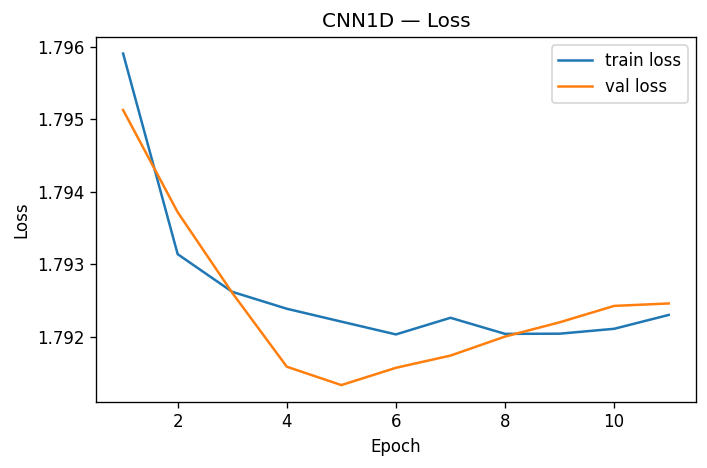

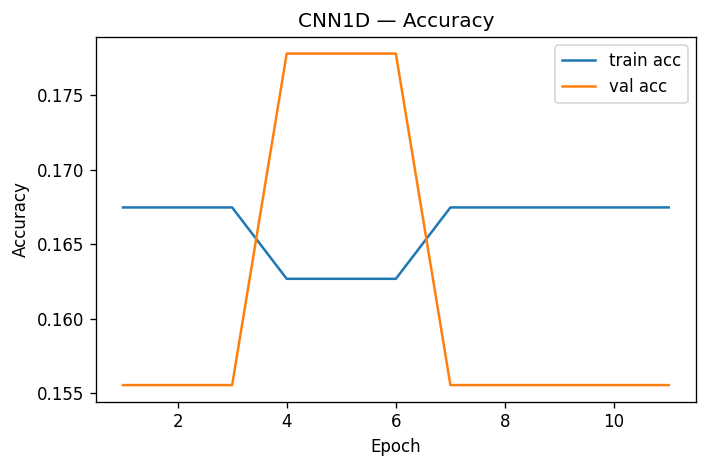

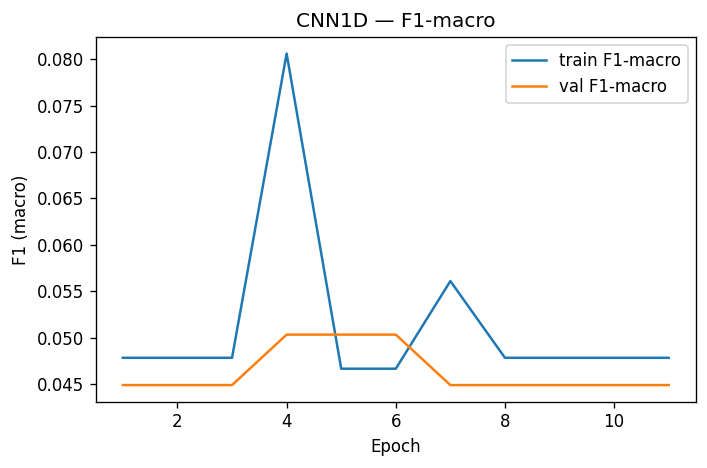

In [70]:
fig, ax = plt.subplots()
ax.plot(history["epoch"], history["train_loss"], label="train loss")
ax.plot(history["epoch"], history["val_loss"],   label="val loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()
ax.set_title("CNN1D — Loss")
plt.tight_layout()
plt.savefig(FIG_CURVE / "cnn1d_loss.png"); plt.show()

fig, ax = plt.subplots()
ax.plot(history["epoch"], history["train_acc"], label="train acc")
ax.plot(history["epoch"], history["val_acc"],   label="val acc")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.legend()
ax.set_title("CNN1D — Accuracy")
plt.tight_layout()
plt.savefig(FIG_CURVE / "cnn1d_acc.png"); plt.show()

fig, ax = plt.subplots()
ax.plot(history["epoch"], history["train_f1"], label="train F1-macro")
ax.plot(history["epoch"], history["val_f1"],   label="val F1-macro")
ax.set_xlabel("Epoch"); ax.set_ylabel("F1 (macro)"); ax.legend()
ax.set_title("CNN1D — F1-macro")
plt.tight_layout()
plt.savefig(FIG_CURVE / "cnn1d_f1.png"); plt.show()


Cell 11 — Load Best Checkpoint & Evaluasi Test

In [72]:
# === Cell 11 — Load Best Checkpoint & Evaluate on Test ===
import json
import numpy as np
import pandas as pd
import torch
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
)

# 1) Load checkpoint (PyTorch 2.6: set weights_only=False)
ckpt_path = CKPT_DIR / "cnn1d_best.pt"
assert ckpt_path.exists(), f"Checkpoint not found: {ckpt_path}"

best = torch.load(ckpt_path, map_location="cpu", weights_only=False)

# Handle both formats: dict with "model" key, or pure state_dict
state_dict = best["model"] if isinstance(best, dict) and "model" in best else best
model.load_state_dict(state_dict)

# 2) Evaluate on test set
model.to(DEVICE)
model.eval()

all_y, all_p = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        # Pastikan dtype float32 agar tidak bentrok dgn AMP/cuda
        xb = xb.to(DEVICE, dtype=torch.float32, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        logits = model(xb)
        preds = logits.argmax(dim=1)

        all_p.append(preds.detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())

all_y = np.concatenate(all_y)
all_p = np.concatenate(all_p)

# 3) Metrics
test_acc = accuracy_score(all_y, all_p)
test_f1m = f1_score(all_y, all_p, average="macro")
print(f"Test ACC: {test_acc:.3f} | F1-macro: {test_f1m:.3f}")

# 4) Classification report & confusion matrix
report = classification_report(all_y, all_p, target_names=CLASS_NAMES, output_dict=True)
report_df = pd.DataFrame(report).transpose()
rep_csv = TABLES_DIR / "cnn1d_test_report.csv"
report_df.to_csv(rep_csv)
print("Saved report:", rep_csv.resolve())

cm = confusion_matrix(all_y, all_p, labels=np.arange(N_CLASSES))
# Simpan CM (npy) agar bisa dipakai cell 12 atau analisis lain
cm_path = TABLES_DIR / "cnn1d_confusion_matrix.npy"
np.save(cm_path, cm)
print("Saved CM array:", cm_path.resolve())

# Simpan ringkasan metrik (JSON) untuk konsistensi
metrics_json = TABLES_DIR / "cnn1d_test_metrics.json"
with open(metrics_json, "w") as f:
    json.dump(
        {"test_acc": float(test_acc), "test_f1_macro": float(test_f1m)},
        f,
        indent=2,
    )
print("Saved metrics:", metrics_json.resolve())

# Tampilkan CM agar bisa langsung dipakai di Cell 12 untuk plotting
cm


Test ACC: 0.174 | F1-macro: 0.049
Saved report: /content/TERS-ML-Portfolio/results/tables/cnn1d_test_report.csv
Saved CM array: /content/TERS-ML-Portfolio/results/tables/cnn1d_confusion_matrix.npy
Saved metrics: /content/TERS-ML-Portfolio/results/tables/cnn1d_test_metrics.json


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


array([[0, 0, 8, 0, 0, 0],
       [0, 0, 7, 0, 0, 0],
       [0, 0, 8, 0, 0, 0],
       [0, 0, 8, 0, 0, 0],
       [0, 0, 7, 0, 0, 0],
       [0, 0, 8, 0, 0, 0]])

Cell 12 — Plot Confusion Matrix

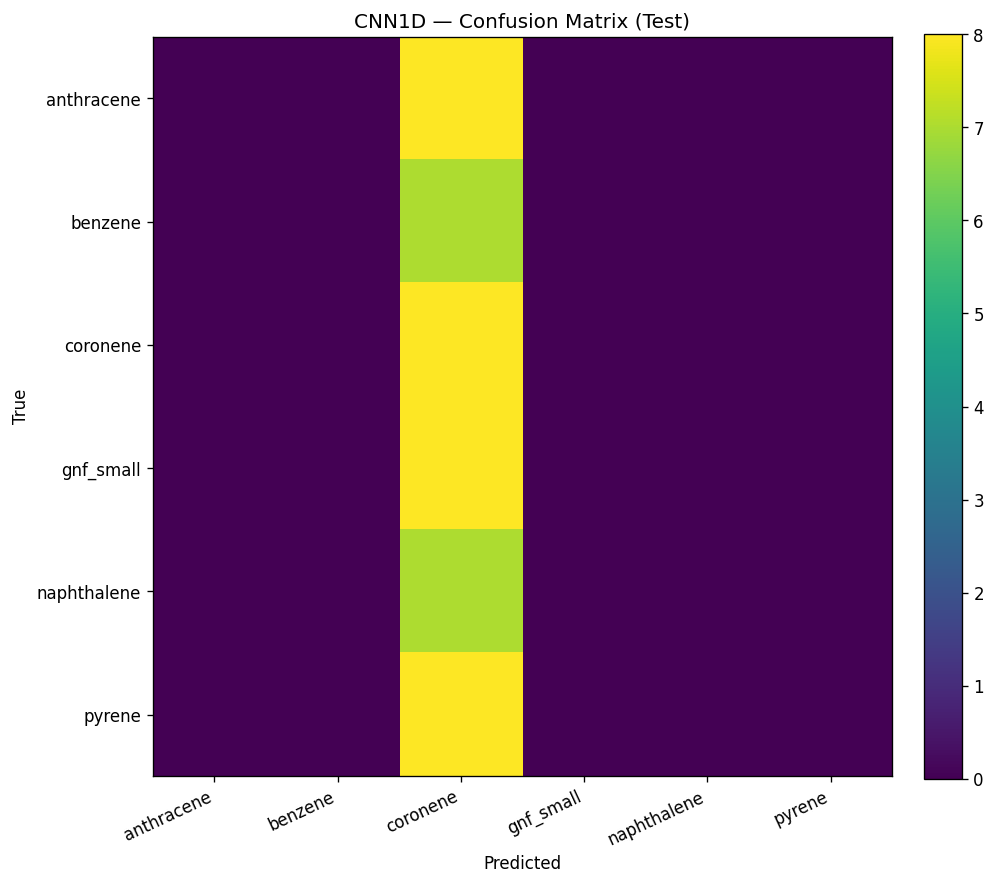

Saved CM: /content/TERS-ML-Portfolio/figures/confusion_matrices/cnn1d_confusion_matrix.png
Saved metrics: /content/TERS-ML-Portfolio/results/tables/cnn1d_test_metrics.json


In [73]:
fig, ax = plt.subplots(figsize=(0.9*len(CLASS_NAMES)+3, 0.9*len(CLASS_NAMES)+3))
im = ax.imshow(cm, interpolation="nearest")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("CNN1D — Confusion Matrix (Test)")
plt.tight_layout()
out_cm = FIG_CM / "cnn1d_confusion_matrix.png"
plt.savefig(out_cm); plt.show()
print("Saved CM:", out_cm.resolve())

# Simpan ringkasan metrik
metrics_json = TABLES_DIR / "cnn1d_test_metrics.json"
with open(metrics_json, "w") as f:
    json.dump({"test_acc": float(test_acc), "test_f1_macro": float(test_f1m)}, f, indent=2)
print("Saved metrics:", metrics_json.resolve())


Cell 13 — Simpan Artefak (Config, Label Classes)

In [74]:
# Simpan info kelas & config supaya inference konsisten
with open(TABLES_DIR / "cnn1d_label_classes.json", "w") as f:
    json.dump({"classes": CLASS_NAMES}, f, indent=2)

with open(TABLES_DIR / "cnn1d_config.json", "w") as f:
    json.dump(best["config"], f, indent=2)

print("Saved label classes & config.")
print("Best checkpoint:", (CKPT_DIR / "cnn1d_best.pt").resolve())


Saved label classes & config.
Best checkpoint: /content/TERS-ML-Portfolio/results/checkpoints/cnn1d_best.pt


Cell 14 — Demo Inference (Random Samples)

Saved: /content/TERS-ML-Portfolio/figures/curves/cnn1d_inference_examples.png


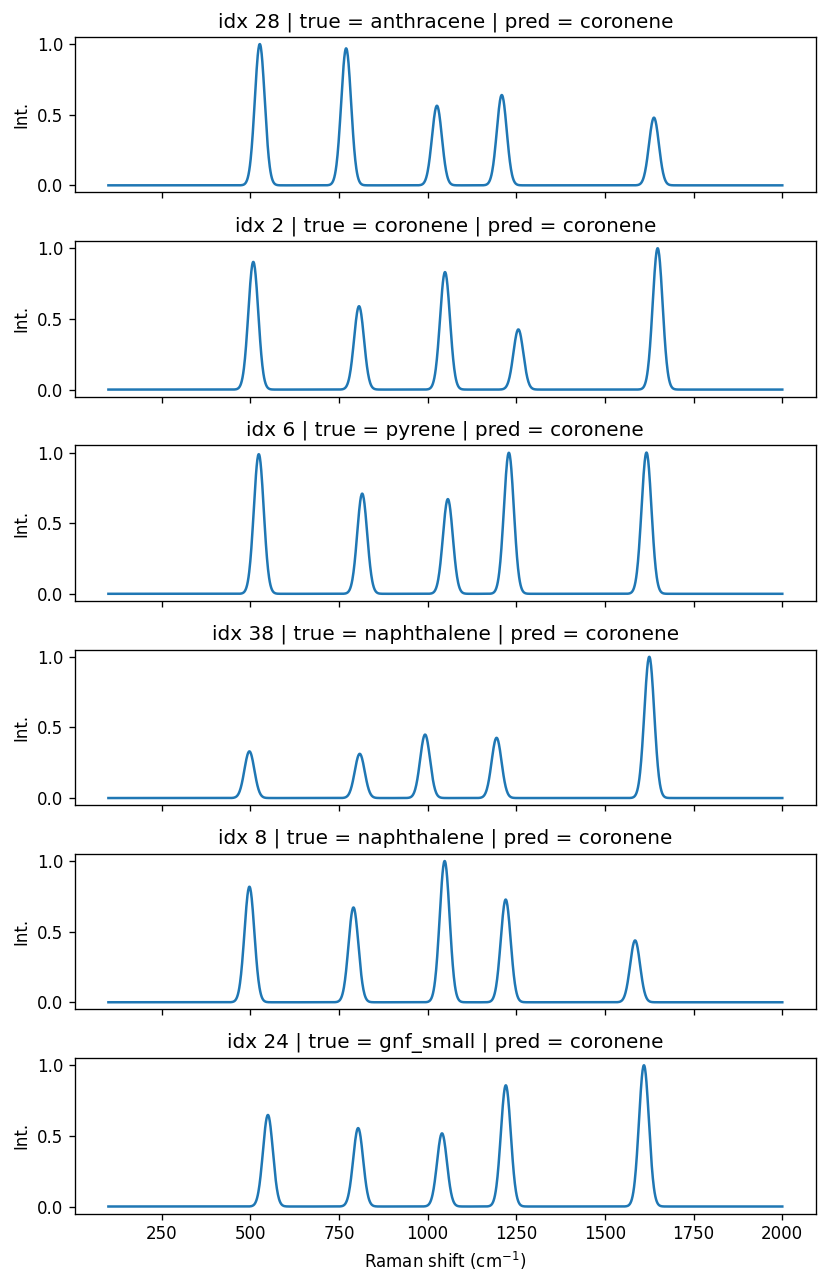

In [75]:
# Ambil beberapa sampel acak dari test set untuk sanity check prediksi
model.eval()
np.random.seed(SEED)
sel = np.random.choice(len(ds_test), size=min(6, len(ds_test)), replace=False)

fig, axes = plt.subplots(len(sel), 1, figsize=(7, 1.8*len(sel)), sharex=True)
for ax, i in zip(axes, sel):
    x, y = ds_test[i]
    with torch.no_grad():
        logits = model(x.unsqueeze(0).to(DEVICE))
        pred = logits.softmax(dim=1).argmax(dim=1).item()
    ax.plot(GRID_test, x.squeeze(0).numpy())
    ax.set_ylabel("Int.")
    ax.set_title(f"idx {i} | true = {CLASS_NAMES[y]} | pred = {CLASS_NAMES[pred]}")
axes[-1].set_xlabel("Raman shift (cm$^{-1}$)")
plt.tight_layout()
plt.savefig(FIG_CURVE / "cnn1d_inference_examples.png")
print("Saved:", (FIG_CURVE / "cnn1d_inference_examples.png").resolve())


Cell 15 — Ringkasan & Next Steps

## ✅ Training CNN 1D Selesai
Artifacts:
- **Checkpoint terbaik**: `results/checkpoints/cnn1d_best.pt`
- **History**: `results/tables/cnn1d_training_history.csv`
- **Test report**: `results/tables/cnn1d_test_report.csv`
- **Test metrics**: `results/tables/cnn1d_test_metrics.json`
- **Classes/Config**: `results/tables/cnn1d_label_classes.json`, `cnn1d_config.json`
- **Figures**:
  - `figures/curves/cnn1d_loss.png`, `cnn1d_acc.png`, `cnn1d_f1.png`, `cnn1d_inference_examples.png`
  - `figures/confusion_matrices/cnn1d_confusion_matrix.png`

### ➡️ Next:
- Latih model 2D (TERS maps) di **`04_train_vit.ipynb`** (ViT/ResNet).
- (Opsional) Coba **multi-task**: klasifikasi + rekonstruksi puncak spektrum.
- (Opsional) Tambah **physics-informed loss** untuk konsistensi tensor/symmetry.


Cell 1 — Judul & Tujuan

# 04 — Train ViT (2D) on TERS Maps
**Tujuan:**

1) Memuat dataset split (`ters_maps_{train,val,test}.npz`) & encoding label,

2) Menyusun `Dataset` + `DataLoader` dengan augmentasi gambar,

3) Melatih **ViT** (timm) untuk klasifikasi TERS maps,

4) Menyimpan checkpoint terbaik + history + metrik,

5) Evaluasi di test set & visualisasi confusion matrix + inference contoh.


Cell 2 — Import & Set Paths

In [76]:
import os, sys, json, random, time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
import torchvision.transforms as T

from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import timm  # sudah diinstall pada 00_setup

# Pastikan project root
PROJECT_ROOT = Path("/content/TERS-ML-Portfolio")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# Direktori
DATA_DIR   = PROJECT_ROOT / "data"
FIG_DIR    = PROJECT_ROOT / "figures" / "ters_maps"
FIG_CM     = PROJECT_ROOT / "figures" / "confusion_matrices"
FIG_CURVE  = PROJECT_ROOT / "figures" / "curves"
CKPT_DIR   = PROJECT_ROOT / "results" / "checkpoints"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
for p in [FIG_DIR, FIG_CM, FIG_CURVE, CKPT_DIR, TABLES_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CWD:", os.getcwd())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")


CWD: /content/TERS-ML-Portfolio
GPU: Tesla T4


Cell 3 — Seed & Device

In [77]:
SEED = 2025
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
USE_AMP = torch.cuda.is_available()  # gunakan mixed precision di GPU
CHANNELS_LAST = True                 # sedikit speedup untuk conv/ViT

print("Seed:", SEED, "| Device:", DEVICE, "| AMP:", USE_AMP, "| channels_last:", CHANNELS_LAST)

import matplotlib as mpl
mpl.rcParams["figure.dpi"] = 120
mpl.rcParams["savefig.dpi"] = 120
mpl.rcParams["figure.figsize"] = (6,4)


Seed: 2025 | Device: cuda | AMP: True | channels_last: True


Cell 4 — Load Splits (NPZ) & Label Encoding

In [78]:
train_npz = np.load(DATA_DIR / "ters_maps_train.npz", allow_pickle=True)
val_npz   = np.load(DATA_DIR / "ters_maps_val.npz",   allow_pickle=True)
test_npz  = np.load(DATA_DIR / "ters_maps_test.npz",  allow_pickle=True)

IMG_train  = train_npz["images"].astype(np.float32)   # (N,H,W) in [0,1]
LABEL_train= train_npz["labels"]                      # array of str

IMG_val  = val_npz["images"].astype(np.float32)
LABEL_val= val_npz["labels"]

IMG_test  = test_npz["images"].astype(np.float32)
LABEL_test= test_npz["labels"]

# Fit label encoder di train
le = LabelEncoder()
y_train = le.fit_transform(LABEL_train)
y_val   = le.transform(LABEL_val)
y_test  = le.transform(LABEL_test)
CLASS_NAMES = list(le.classes_)
N_CLASSES = len(CLASS_NAMES)

print("Classes:", CLASS_NAMES)
print("Shapes:", IMG_train.shape, IMG_val.shape, IMG_test.shape)


Classes: ['anthracene', 'benzene', 'coronene', 'gnf_small', 'naphthalene', 'pyrene']
Shapes: (251, 96, 96) (54, 96, 96) (55, 96, 96)


Cell 5 — Transforms & Dataset

In [79]:
# ViT timm 'vit_tiny_patch16_224' mengharapkan input 224x224 RGB
IMG_SIZE = 224

# Helper: numpy (H,W) float32 [0..1] -> PIL RGB
def to_pil_rgb(img2d: np.ndarray) -> Image.Image:
    x = (np.clip(img2d, 0.0, 1.0) * 255.0).astype(np.uint8)
    pil = Image.fromarray(x, mode="L").convert("RGB")
    return pil

# Augmentasi train
train_tfms = T.Compose([
    T.RandomResizedCrop(IMG_SIZE, scale=(0.7, 1.0), ratio=(0.9, 1.1)),
    T.RandomHorizontalFlip(),
    T.RandomVerticalFlip(),
    T.RandomRotation(10),
    T.ToTensor(),                          # [0..1], shape (3,H,W)
    T.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),  # -> [-1,1]
])

# Val/Test transform
eval_tfms = T.Compose([
    T.Resize(IMG_SIZE),
    T.CenterCrop(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=(0.5,0.5,0.5), std=(0.5,0.5,0.5)),
])

class TERSMapDataset(Dataset):
    def __init__(self, images: np.ndarray, labels: np.ndarray, transform, seed=SEED):
        self.images = images.astype(np.float32)
        self.labels = labels.astype(np.int64)
        self.transform = transform

    def __len__(self):
        return self.images.shape[0]

    def __getitem__(self, idx):
        img = self.images[idx]     # (H,W) float32
        y   = self.labels[idx]     # int
        pil = to_pil_rgb(img)
        x   = self.transform(pil).to(torch.float32)  # (3,H,W)
        return x, torch.tensor(y, dtype=torch.long)


Cell 6 — DataLoaders & Class Weights

In [80]:
BATCH_SIZE = 32
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

ds_train = TERSMapDataset(IMG_train, y_train, transform=train_tfms, seed=SEED)
ds_val   = TERSMapDataset(IMG_val,   y_val,   transform=eval_tfms,  seed=SEED+1)
ds_test  = TERSMapDataset(IMG_test,  y_test,  transform=eval_tfms,  seed=SEED+2)

train_loader = DataLoader(ds_train, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(ds_val,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(ds_test,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

# Class weights untuk CE (optional)
class_counts = np.bincount(y_train, minlength=N_CLASSES)
class_weights = (class_counts.sum() / np.maximum(class_counts, 1)).astype(np.float32)
class_weights = class_weights / class_weights.mean()
print("class_counts:", class_counts)
print("class_weights:", class_weights)


class_counts: [42 42 41 42 42 42]
class_weights: [0.99595135 0.99595135 1.0202428  0.99595135 0.99595135 0.99595135]


Cell 7 — Model (timm ViT), Optimizer, Scheduler

In [81]:
MODEL_NAME = "vit_tiny_patch16_224"  # kecil & cepat; hindari pretrained (butuh internet)
model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=N_CLASSES)

if CHANNELS_LAST:
    model = model.to(memory_format=torch.channels_last)

model = model.to(DEVICE)
criterion = nn.CrossEntropyLoss(weight=torch.tensor(class_weights, device=DEVICE))
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=0.05)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=30)

print(MODEL_NAME, "params:", sum(p.numel() for p in model.parameters())/1e6, "M")


vit_tiny_patch16_224 params: 5.525574 M


Cell 8 — Train/Eval Loop (AMP-safe)

In [82]:
from contextlib import nullcontext
from torch.amp import autocast
from torch.cuda.amp import GradScaler

scaler = GradScaler(enabled=USE_AMP)

def epoch_step(loader, train=True):
    model.train(mode=train)
    total_loss, n, all_y, all_p = 0.0, 0, [], []
    amp_ctx = autocast(device_type="cuda", enabled=USE_AMP) if DEVICE.type == "cuda" else nullcontext()

    for xb, yb in loader:
        if CHANNELS_LAST:
            xb = xb.to(DEVICE, dtype=torch.float32, memory_format=torch.channels_last, non_blocking=True)
        else:
            xb = xb.to(DEVICE, dtype=torch.float32, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        with torch.set_grad_enabled(train):
            with amp_ctx:
                logits = model(xb)
                loss = criterion(logits, yb)

            if train:
                optimizer.zero_grad(set_to_none=True)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()

        total_loss += loss.item() * xb.size(0)
        n += xb.size(0)

        preds = logits.argmax(dim=1)
        all_p.append(preds.detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())

    all_y = np.concatenate(all_y)
    all_p = np.concatenate(all_p)
    acc = accuracy_score(all_y, all_p)
    f1m = f1_score(all_y, all_p, average="macro")
    return total_loss / n, acc, f1m


/tmp/ipython-input-1544676457.py:5: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=USE_AMP)


Cell 9 — Training dengan Early Stopping

In [83]:
EPOCHS = 30
PATIENCE = 8
best_val = -np.inf
best_state = None
history = {"epoch":[], "train_loss":[], "train_acc":[], "train_f1":[], "val_loss":[], "val_acc":[], "val_f1":[]}
no_improve = 0

for epoch in range(1, EPOCHS+1):
    t0 = time.time()
    tr_loss, tr_acc, tr_f1 = epoch_step(train_loader, train=True)
    val_loss, val_acc, val_f1 = epoch_step(val_loader,   train=False)
    scheduler.step()

    history["epoch"].append(epoch)
    history["train_loss"].append(tr_loss); history["train_acc"].append(tr_acc); history["train_f1"].append(tr_f1)
    history["val_loss"].append(val_loss);   history["val_acc"].append(val_acc);  history["val_f1"].append(val_f1)

    print(f"Epoch {epoch:02d} | "
          f"train loss {tr_loss:.4f} acc {tr_acc:.3f} f1 {tr_f1:.3f} | "
          f"val loss {val_loss:.4f} acc {val_acc:.3f} f1 {val_f1:.3f} | "
          f"{time.time()-t0:.1f}s")

    # early stopping on val_f1
    if val_f1 > best_val:
        best_val = val_f1
        best_state = {
            "model": model.state_dict(),
            "epoch": int(epoch),
            "val_f1": float(val_f1),
            "val_acc": float(val_acc),
            "config": {
                "epochs": int(EPOCHS), "batch_size": int(BATCH_SIZE),
                "lr": float(3e-4), "weight_decay": float(0.05),
                "scheduler": "CosineAnnealingLR(T_max=30)",
                "seed": int(SEED), "amp": bool(USE_AMP), "arch": MODEL_NAME,
                "img_size": int(IMG_SIZE), "channels_last": bool(CHANNELS_LAST),
            },
            "classes": list(CLASS_NAMES),
        }
        torch.save(best_state, CKPT_DIR / "vit_best.pt")
        no_improve = 0
    else:
        no_improve += 1

    if no_improve >= PATIENCE:
        print(f"Early stopping at epoch {epoch} (no improvement {PATIENCE} epochs).")
        break

# save history
hist_df = pd.DataFrame(history)
hist_csv = TABLES_DIR / "vit_training_history.csv"
hist_df.to_csv(hist_csv, index=False)
print("Saved history:", hist_csv.resolve())


/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")


Epoch 01 | train loss 2.0775 acc 0.159 f1 0.125 | val loss 1.8694 acc 0.167 f1 0.048 | 1.6s


/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")


Epoch 02 | train loss 1.8556 acc 0.139 f1 0.068 | val loss 1.8075 acc 0.167 f1 0.048 | 1.1s


/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")


...

Epoch 28 | train loss 1.7824 acc 0.199 f1 0.122 | val loss 1.7769 acc 0.222 f1 0.117 | 1.1s


/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")


Epoch 29 | train loss 1.7792 acc 0.175 f1 0.100 | val loss 1.7769 acc 0.222 f1 0.117 | 1.1s


/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")


Epoch 30 | train loss 1.7777 acc 0.199 f1 0.125 | val loss 1.7770 acc 0.222 f1 0.117 | 1.1s
Early stopping at epoch 30 (no improvement 8 epochs).
Saved history: /content/TERS-ML-Portfolio/results/tables/vit_training_history.csv


Cell 10 — Plot Kurva Training

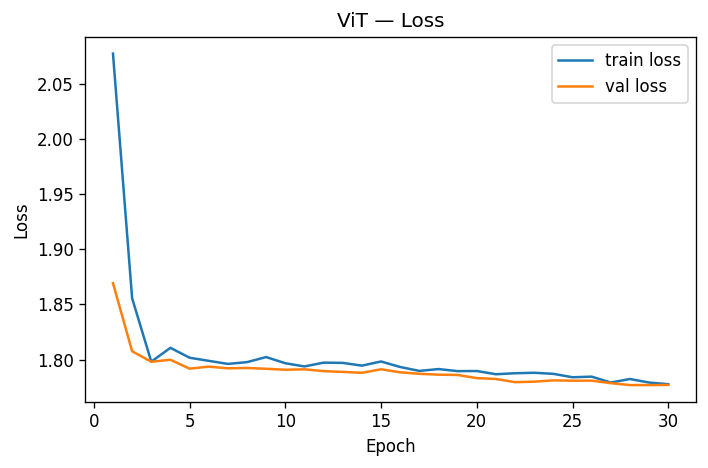

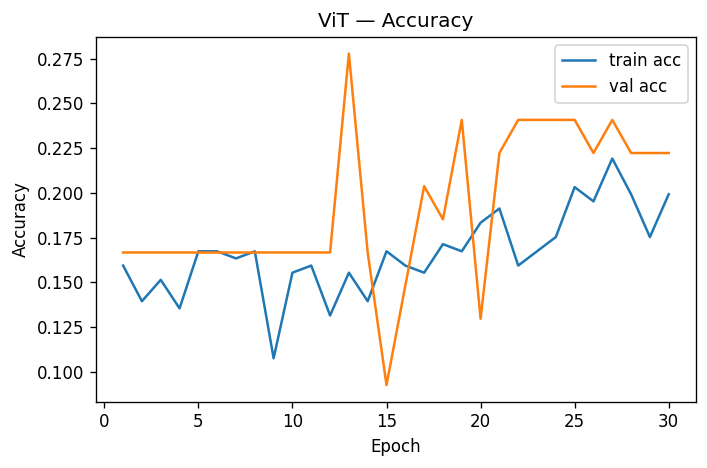

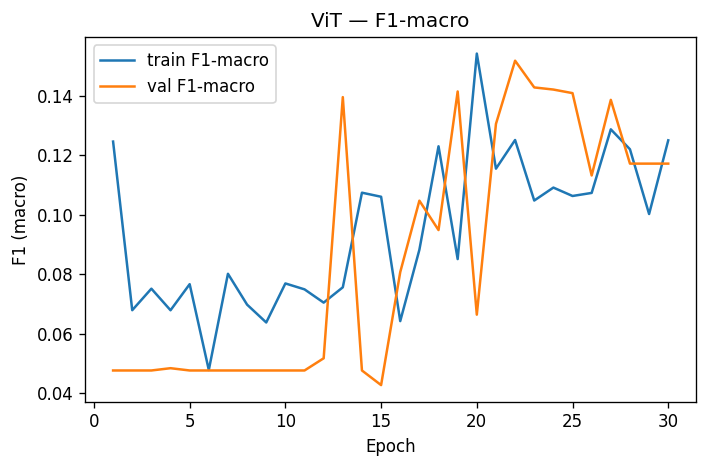

In [84]:
fig, ax = plt.subplots()
ax.plot(history["epoch"], history["train_loss"], label="train loss")
ax.plot(history["epoch"], history["val_loss"],   label="val loss")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend(); ax.set_title("ViT — Loss")
plt.tight_layout(); plt.savefig(FIG_CURVE / "vit_loss.png"); plt.show()

fig, ax = plt.subplots()
ax.plot(history["epoch"], history["train_acc"], label="train acc")
ax.plot(history["epoch"], history["val_acc"],   label="val acc")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.legend(); ax.set_title("ViT — Accuracy")
plt.tight_layout(); plt.savefig(FIG_CURVE / "vit_acc.png"); plt.show()

fig, ax = plt.subplots()
ax.plot(history["epoch"], history["train_f1"], label="train F1-macro")
ax.plot(history["epoch"], history["val_f1"],   label="val F1-macro")
ax.set_xlabel("Epoch"); ax.set_ylabel("F1 (macro)"); ax.legend(); ax.set_title("ViT — F1-macro")
plt.tight_layout(); plt.savefig(FIG_CURVE / "vit_f1.png"); plt.show()


Cell 11 — Load Best & Evaluasi Test

In [85]:
# PyTorch 2.6: set weights_only=False agar kompatibel dg dict checkpoint
ckpt_path = CKPT_DIR / "vit_best.pt"
best = torch.load(ckpt_path, map_location="cpu", weights_only=False)
state_dict = best["model"] if isinstance(best, dict) and "model" in best else best
model.load_state_dict(state_dict)

model.to(DEVICE); model.eval()

all_y, all_p = [], []
with torch.no_grad():
    for xb, yb in test_loader:
        if CHANNELS_LAST:
            xb = xb.to(DEVICE, dtype=torch.float32, memory_format=torch.channels_last, non_blocking=True)
        else:
            xb = xb.to(DEVICE, dtype=torch.float32, non_blocking=True)
        yb = yb.to(DEVICE, non_blocking=True)

        logits = model(xb)
        preds = logits.argmax(dim=1)

        all_p.append(preds.detach().cpu().numpy())
        all_y.append(yb.detach().cpu().numpy())

all_y = np.concatenate(all_y)
all_p = np.concatenate(all_p)

test_acc = accuracy_score(all_y, all_p)
test_f1m = f1_score(all_y, all_p, average="macro")
print(f"Test ACC: {test_acc:.3f} | F1-macro: {test_f1m:.3f}")

# report + cm
report = classification_report(all_y, all_p, target_names=CLASS_NAMES, output_dict=True)
report_df = pd.DataFrame(report).transpose()
rep_csv = TABLES_DIR / "vit_test_report.csv"
report_df.to_csv(rep_csv); print("Saved:", rep_csv.resolve())

cm = confusion_matrix(all_y, all_p, labels=np.arange(N_CLASSES))
np.save(TABLES_DIR / "vit_confusion_matrix.npy", cm)
with open(TABLES_DIR / "vit_test_metrics.json", "w") as f:
    json.dump({"test_acc": float(test_acc), "test_f1_macro": float(test_f1m)}, f, indent=2)


/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")
/tmp/ipython-input-2630503605.py:7: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray(x, mode="L").convert("RGB")


Test ACC: 0.145 | F1-macro: 0.098
Saved: /content/TERS-ML-Portfolio/results/tables/vit_test_report.csv


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Cell 12 — Plot Confusion Matrix

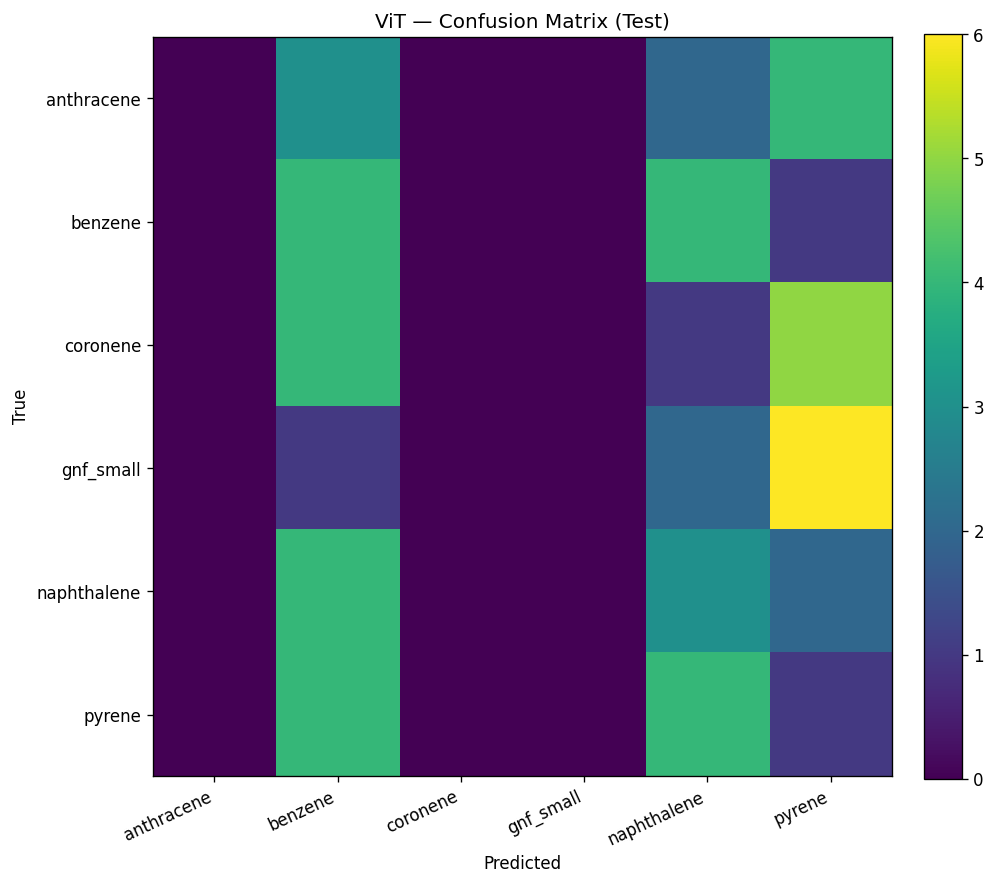

Saved CM: /content/TERS-ML-Portfolio/figures/confusion_matrices/vit_confusion_matrix.png


In [86]:
fig, ax = plt.subplots(figsize=(0.9*len(CLASS_NAMES)+3, 0.9*len(CLASS_NAMES)+3))
im = ax.imshow(cm, interpolation="nearest")
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
ax.set_xticks(range(N_CLASSES)); ax.set_yticks(range(N_CLASSES))
ax.set_xticklabels(CLASS_NAMES, rotation=25, ha="right")
ax.set_yticklabels(CLASS_NAMES)
ax.set_xlabel("Predicted"); ax.set_ylabel("True")
ax.set_title("ViT — Confusion Matrix (Test)")
plt.tight_layout()
out_cm = FIG_CM / "vit_confusion_matrix.png"
plt.savefig(out_cm); plt.show()
print("Saved CM:", out_cm.resolve())


Cell 13 — Inference Montage (Contoh Prediksi Test)

/tmp/ipython-input-1487052302.py:14: DeprecationWarning: 'mode' parameter is deprecated and will be removed in Pillow 13 (2026-10-15)
  pil = Image.fromarray((IMG_test[i]*255).astype(np.uint8), mode="L").convert("RGB")


Saved: /content/TERS-ML-Portfolio/figures/ters_maps/vit_inference_montage.png


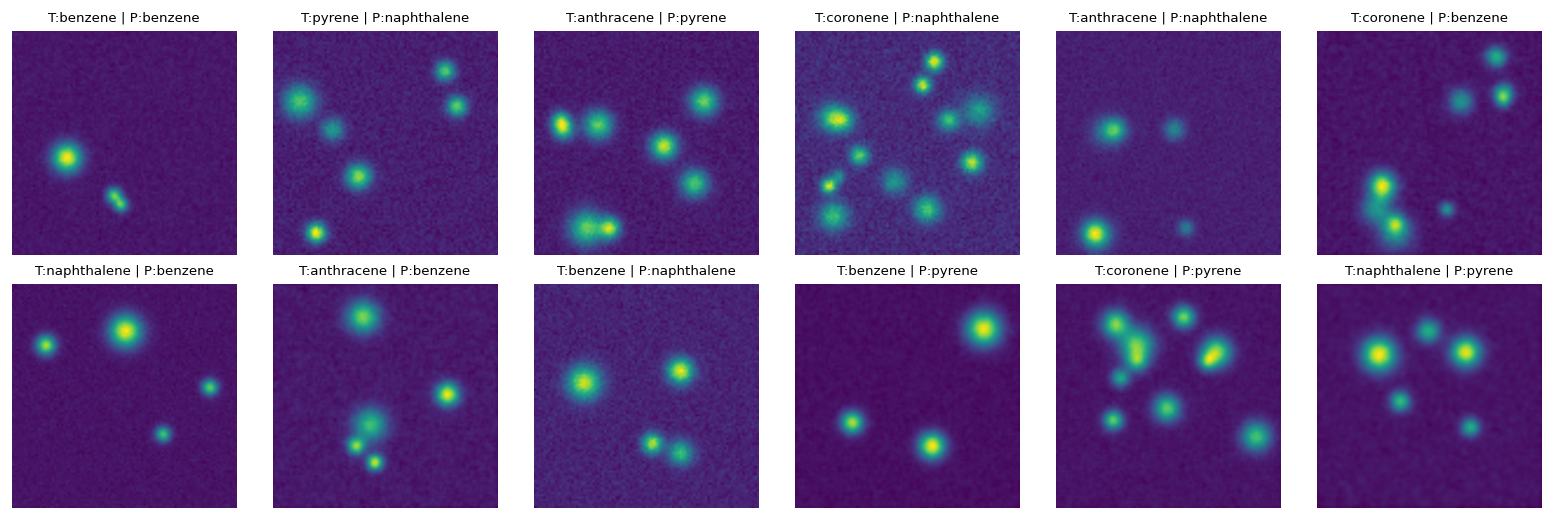

In [87]:
# Ambil beberapa contoh acak dari test set
np.random.seed(SEED)
sel = np.random.choice(len(ds_test), size=min(12, len(ds_test)), replace=False)

# Untuk mem-visual-kan, ambil image asli (grayscale) tanpa transform
raw_imgs = IMG_test[sel]         # (k,H,W) float32 [0..1]
true_ids = y_test[sel]

# Prediksi
model.eval()
pred_ids = []
with torch.no_grad():
    for i in sel:
        pil = Image.fromarray((IMG_test[i]*255).astype(np.uint8), mode="L").convert("RGB")
        x = eval_tfms(pil).unsqueeze(0).to(DEVICE, dtype=torch.float32)
        pred = model(x).argmax(dim=1).item()
        pred_ids.append(pred)
pred_ids = np.array(pred_ids)

# Plot grid
cols = 6
rows = int(np.ceil(len(sel)/cols))
fig, axes = plt.subplots(rows, cols, figsize=(2.2*cols, 2.2*rows))
axes = axes.ravel()
for ax, i, y_t, y_p in zip(axes, sel, true_ids, pred_ids):
    ax.imshow(raw_imgs[np.where(sel==i)[0][0]], cmap="viridis", origin="lower", interpolation="bilinear")
    ax.set_title(f"T:{CLASS_NAMES[y_t]} | P:{CLASS_NAMES[y_p]}", fontsize=8)
    ax.axis("off")
for ax in axes[len(sel):]:
    ax.axis("off")
plt.tight_layout()
out_path = FIG_DIR / "vit_inference_montage.png"
plt.savefig(out_path, dpi=140)
print("Saved:", out_path.resolve())


Cell 14 — Simpan Artefak & Ringkasan

In [88]:
# Simpan kelas & config untuk inference
with open(TABLES_DIR / "vit_label_classes.json", "w") as f:
    json.dump({"classes": CLASS_NAMES}, f, indent=2)

# Simpan pure weights-only agar kompatibel ke depan
torch.save(model.state_dict(), CKPT_DIR / "vit_weights_only.pt")
print("Saved weights-only:", (CKPT_DIR / "vit_weights_only.pt").resolve())

# Ringkasan
print("Best checkpoint:", (CKPT_DIR / "vit_best.pt").resolve())
print("Figures saved to:", FIG_DIR.resolve(), FIG_CM.resolve(), FIG_CURVE.resolve())
print("Tables saved to:", TABLES_DIR.resolve())


Saved weights-only: /content/TERS-ML-Portfolio/results/checkpoints/vit_weights_only.pt
Best checkpoint: /content/TERS-ML-Portfolio/results/checkpoints/vit_best.pt
Figures saved to: /content/TERS-ML-Portfolio/figures/ters_maps /content/TERS-ML-Portfolio/figures/confusion_matrices /content/TERS-ML-Portfolio/figures/curves
Tables saved to: /content/TERS-ML-Portfolio/results/tables


Cell 1 — Judul & Tujuan

# 05 — Results & Visualization Dashboard
**Tujuan:**

1) Memuat artefak hasil training: history, metrik, confusion matrix, dan figures,

2) Membuat visualisasi gabungan (kurva training, confusion matrix, per-class F1),

3) Menyusun tabel ringkasan metrik (CNN vs ViT) dan menyimpan ke CSV/Markdown,

4) Menampilkan sampel inference (jika artefak gambar tersedia).


Cell 2 — Import & Paths

In [89]:
import os, sys, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Pastikan project root & CWD
PROJECT_ROOT = Path("/content/TERS-ML-Portfolio")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# Direktori artefak
FIG_CURVE  = PROJECT_ROOT / "figures" / "curves"
FIG_CM     = PROJECT_ROOT / "figures" / "confusion_matrices"
FIG_SPEC   = PROJECT_ROOT / "figures" / "spectra"
FIG_TERS   = PROJECT_ROOT / "figures" / "ters_maps"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
CKPT_DIR   = PROJECT_ROOT / "results" / "checkpoints"

for p in [FIG_CURVE, FIG_CM, FIG_SPEC, FIG_TERS, TABLES_DIR, CKPT_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CWD:", os.getcwd())


CWD: /content/TERS-ML-Portfolio


Cell 3 — Load Metrics & Reports (CNN & ViT)

In [90]:
# Paths untuk CNN
cnn_hist_csv   = TABLES_DIR / "cnn1d_training_history.csv"
cnn_metrics_js = TABLES_DIR / "cnn1d_test_metrics.json"
cnn_report_csv = TABLES_DIR / "cnn1d_test_report.csv"
cnn_cm_npy     = TABLES_DIR / "cnn1d_confusion_matrix.npy"
cnn_classes_js = TABLES_DIR / "cnn1d_label_classes.json"

# Paths untuk ViT
vit_hist_csv   = TABLES_DIR / "vit_training_history.csv"
vit_metrics_js = TABLES_DIR / "vit_test_metrics.json"
vit_report_csv = TABLES_DIR / "vit_test_report.csv"
vit_cm_npy     = TABLES_DIR / "vit_confusion_matrix.npy"
vit_classes_js = TABLES_DIR / "vit_label_classes.json"

# Load aman (dengan fallback sederhana)
def load_json(p):
    if p.exists():
        with open(p, "r") as f:
            return json.load(f)
    return {}

def load_csv(p):
    return pd.read_csv(p) if p.exists() else pd.DataFrame()

def load_npy(p):
    return np.load(p) if p.exists() else None

cnn_hist   = load_csv(cnn_hist_csv)
vit_hist   = load_csv(vit_hist_csv)
cnn_metrics= load_json(cnn_metrics_js)
vit_metrics= load_json(vit_metrics_js)
cnn_report = load_csv(cnn_report_csv)
vit_report = load_csv(vit_report_csv)
cnn_cm     = load_npy(cnn_cm_npy)
vit_cm     = load_npy(vit_cm_npy)
cnn_classes= load_json(cnn_classes_js).get("classes", [])
vit_classes= load_json(vit_classes_js).get("classes", [])

print("CNN history:", cnn_hist.shape, "| ViT history:", vit_hist.shape)
print("CNN metrics:", cnn_metrics)
print("ViT metrics:", vit_metrics)
print("CNN classes:", cnn_classes)
print("ViT classes:", vit_classes)


CNN history: (11, 7) | ViT history: (30, 7)
CNN metrics: {'test_acc': 0.17391304347826086, 'test_f1_macro': 0.04938271604938271}
ViT metrics: {'test_acc': 0.14545454545454545, 'test_f1_macro': 0.09788177339901477}
CNN classes: ['anthracene', 'benzene', 'coronene', 'gnf_small', 'naphthalene', 'pyrene']
ViT classes: ['anthracene', 'benzene', 'coronene', 'gnf_small', 'naphthalene', 'pyrene']


Cell 4 — Plot Kurva Training (CNN & ViT)

In [ ]:
# CNN curves
if not cnn_hist.empty:
    fig, ax = plt.subplots()
    ax.plot(cnn_hist["epoch"], cnn_hist["train_loss"], label="train loss")
    ax.plot(cnn_hist["epoch"], cnn_hist["val_loss"],   label="val loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()
    ax.set_title("CNN1D — Loss")
    plt.tight_layout(); plt.savefig(FIG_CURVE / "cnn1d_loss_replot.png"); plt.show()

    fig, ax = plt.subplots()
    ax.plot(cnn_hist["epoch"], cnn_hist["train_acc"], label="train acc")
    ax.plot(cnn_hist["epoch"], cnn_hist["val_acc"],   label="val acc")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.legend()
    ax.set_title("CNN1D — Accuracy")
    plt.tight_layout(); plt.savefig(FIG_CURVE / "cnn1d_acc_replot.png"); plt.show()

    fig, ax = plt.subplots()
    ax.plot(cnn_hist["epoch"], cnn_hist["train_f1"], label="train F1")
    ax.plot(cnn_hist["epoch"], cnn_hist["val_f1"],   label="val F1")
    ax.set_xlabel("Epoch"); ax.set_ylabel("F1 (macro)"); ax.legend()
    ax.set_title("CNN1D — F1-macro")
    plt.tight_layout(); plt.savefig(FIG_CURVE / "cnn1d_f1_replot.png"); plt.show()
else:
    print("CNN history CSV not found — skipping.")

# ViT curves
if not vit_hist.empty:
    fig, ax = plt.subplots()
    ax.plot(vit_hist["epoch"], vit_hist["train_loss"], label="train loss")
    ax.plot(vit_hist["epoch"], vit_hist["val_loss"],   label="val loss")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Loss"); ax.legend()
    ax.set_title("ViT — Loss")
    plt.tight_layout(); plt.savefig(FIG_CURVE / "vit_loss_replot.png"); plt.show()

    fig, ax = plt.subplots()
    ax.plot(vit_hist["epoch"], vit_hist["train_acc"], label="train acc")
    ax.plot(vit_hist["epoch"], vit_hist["val_acc"],   label="val acc")
    ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy"); ax.legend()
    ax.set_title("ViT — Accuracy")
    plt.tight_layout(); plt.savefig(FIG_CURVE / "vit_acc_replot.png"); plt.show()

    fig, ax = plt.subplots()
    ax.plot(vit_hist["epoch"], vit_hist["train_f1"], label="train F1")
    ax.plot(vit_hist["epoch"], vit_hist["val_f1"],   label="val F1")
    ax.set_xlabel("Epoch"); ax.set_ylabel("F1 (macro)"); ax.legend()
    ax.set_title("ViT — F1-macro")
    plt.tight_layout(); plt.savefig(FIG_CURVE / "vit_f1_replot.png"); plt.show()
else:
    print("ViT history CSV not found — skipping.")


Cell 5 — Confusion Matrix (CNN & ViT)

In [ ]:
# Plot helper
def plot_cm(cm, class_names, title, out_png):
    fig, ax = plt.subplots(figsize=(0.9*len(class_names)+3, 0.9*len(class_names)+3))
    im = ax.imshow(cm, interpolation="nearest")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    ax.set_xticks(range(len(class_names))); ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=25, ha="right")
    ax.set_yticklabels(class_names)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_title(title)
    plt.tight_layout(); plt.savefig(out_png); plt.show()
    print("Saved CM:", out_png)

if cnn_cm is not None and len(cnn_classes)>0:
    plot_cm(cnn_cm, cnn_classes, "CNN1D — Confusion Matrix (Test)", FIG_CM / "cnn1d_confusion_matrix_replot.png")
else:
    print("CNN CM not found — skipping.")

if vit_cm is not None and len(vit_classes)>0:
    plot_cm(vit_cm, vit_classes, "ViT — Confusion Matrix (Test)", FIG_CM / "vit_confusion_matrix_replot.png")
else:
    print("ViT CM not found — skipping.")


Cell 6 — Per-Class Metrics (F1, Precision, Recall)

In [ ]:
# Ambil per-class dari classification_report.csv (baris class names)
def per_class_from_report(df):
    if df.empty:
        return pd.DataFrame()
    # filter rows yang nama index-nya adalah kelas (bukan 'accuracy','macro avg','weighted avg')
    mask = (~df["precision"].isna()) & (~df["recall"].isna()) & (~df["f1-score"].isna())
    sub = df[mask].copy()
    # kolom 'Unnamed: 0' biasanya nama kelas setelah read_csv; handle jika index disimpan
    if "Unnamed: 0" in sub.columns:
        sub = sub.rename(columns={"Unnamed: 0": "class"})
    elif df.index.name is not None or isinstance(df.index, pd.RangeIndex) is False:
        sub = sub.reset_index().rename(columns={"index": "class"})
    else:
        # fallback: buat kolom class jika tidak ada
        sub.insert(0, "class", [f"class_{i}" for i in range(len(sub))])
    return sub[["class", "precision", "recall", "f1-score", "support"]]

cnn_pc = per_class_from_report(cnn_report)
vit_pc = per_class_from_report(vit_report)

# Merge by class (asumsi nama kelas konsisten; jika tidak, lakukan map manual)
merged = None
if not cnn_pc.empty and not vit_pc.empty:
    merged = pd.merge(cnn_pc, vit_pc, on="class", suffixes=("_cnn", "_vit"))
    display_cols = ["class", "f1-score_cnn", "f1-score_vit", "precision_cnn", "precision_vit", "recall_cnn", "recall_vit", "support_cnn", "support_vit"]
    merged = merged[display_cols].sort_values("class")
    merged_path = TABLES_DIR / "per_class_metrics_cnn_vs_vit.csv"
    merged.to_csv(merged_path, index=False)
    print("Saved per-class merged:", merged_path.resolve())
    merged.head()
else:
    print("Per-class report missing for CNN or ViT — skipping merged table.")
    merged


Cell 7 — Plot Per-Class F1: CNN vs ViT (Grouped Bar)

In [ ]:
if merged is not None and not merged.empty:
    classes = merged["class"].values
    f1_cnn = merged["f1-score_cnn"].values
    f1_vit = merged["f1-score_vit"].values

    x = np.arange(len(classes))
    width = 0.35

    fig, ax = plt.subplots(figsize=(max(6, 0.6*len(classes)+2), 4.5))
    ax.bar(x - width/2, f1_cnn, width, label="CNN (1D spectra)")
    ax.bar(x + width/2, f1_vit, width, label="ViT (TERS maps)")
    ax.set_xticks(x); ax.set_xticklabels(classes, rotation=25, ha="right")
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.0)
    ax.set_title("Per-class F1 — CNN vs ViT")
    ax.legend()
    plt.tight_layout()
    out_path = FIG_CURVE / "per_class_f1_cnn_vs_vit.png"
    plt.savefig(out_path); plt.show()
    print("Saved:", out_path.resolve())
else:
    print("Merged per-class metrics not available — skipping plot.")


Cell 8 — Summary Table (Overall Metrics)

In [ ]:
summary_rows = []
if cnn_metrics:
    summary_rows.append({"model": "CNN1D (spectra)", "test_acc": cnn_metrics.get("test_acc", None), "test_f1_macro": cnn_metrics.get("test_f1_macro", None)})
if vit_metrics:
    summary_rows.append({"model": "ViT (TERS maps)", "test_acc": vit_metrics.get("test_acc", None), "test_f1_macro": vit_metrics.get("test_f1_macro", None)})

summary_df = pd.DataFrame(summary_rows)
summary_csv = TABLES_DIR / "summary_models.csv"
summary_df.to_csv(summary_csv, index=False)
print("Saved:", summary_csv.resolve())
summary_df


Cell 9 — Tampilkan Artefak Gambar yang Sudah Ada (Opsional)

In [ ]:
def show_image_if_exists(path, title=None):
    if path.exists():
        img = plt.imread(path)
        plt.figure(figsize=(6,4))
        plt.imshow(img)
        plt.axis("off")
        if title: plt.title(title)
        plt.tight_layout()
        plt.show()
    else:
        print("Not found:", path)

# Dari notebook sebelumnya (jika ada)
show_image_if_exists(FIG_CURVE / "cnn1d_inference_examples.png", "CNN1D — Inference Examples")
show_image_if_exists(FIG_TERS / "vit_inference_montage.png",   "ViT — Inference Montage")

# Confusion matrix yang sudah disimpan sebelumnya
show_image_if_exists(FIG_CM / "cnn1d_confusion_matrix.png", "CNN1D — CM (from 03)")
show_image_if_exists(FIG_CM / "vit_confusion_matrix.png",   "ViT — CM (from 04)")


Cell 10 — Export Ringkasan Markdown (results/summary.md)

In [ ]:
lines = []
lines.append("# Results Summary\n")
lines.append("## Overall Metrics\n")
if not summary_df.empty:
    for _, r in summary_df.iterrows():
        lines.append(f"- **{r['model']}**: ACC = {r['test_acc']:.3f}, F1-macro = {r['test_f1_macro']:.3f}")
else:
    lines.append("- (no summary_df)\n")

lines.append("\n## Figures\n")
for p in [
    FIG_CURVE / "cnn1d_loss_replot.png",
    FIG_CURVE / "cnn1d_acc_replot.png",
    FIG_CURVE / "cnn1d_f1_replot.png",
    FIG_CM / "cnn1d_confusion_matrix_replot.png",
    FIG_CURVE / "vit_loss_replot.png",
    FIG_CURVE / "vit_acc_replot.png",
    FIG_CURVE / "vit_f1_replot.png",
    FIG_CM / "vit_confusion_matrix_replot.png",
    FIG_CURVE / "per_class_f1_cnn_vs_vit.png",
    FIG_CURVE / "cnn1d_inference_examples.png",
    FIG_TERS / "vit_inference_montage.png",
]:
    if p.exists():
        lines.append(f"- {p.relative_to(PROJECT_ROOT)}")

out_md = TABLES_DIR / "summary.md"
out_md.write_text("\n".join(lines))
print("Saved:", out_md.resolve())
print("\n".join(lines[:12]), "\n...")


Cell 11 — Selesai & Next Steps

## ✅ Results Visualization Selesai
Artifacts utama:
- **Tabel ringkasan:** `results/tables/summary_models.csv`
- **Markdown ringkasan:** `results/tables/summary.md`
- **Per-class metrics (merged):** `results/tables/per_class_metrics_cnn_vs_vit.csv`
- **Figuras kurva & CM (replot):** `figures/curves/*_replot.png`, `figures/confusion_matrices/*_replot.png`
- **Inference figures (jika ada):** `figures/curves/cnn1d_inference_examples.png`, `figures/ters_maps/vit_inference_montage.png`

### ➡️ Next:
- Buat ringkasan yang siap-pakai PDF di **`06_summary_report.ipynb`** (opsional, untuk CV/lamaran).
- Tambahkan ablation study (mis. ukuran data, noise level) dan sertakan ke tabel & visual.


Cell 1 — Judul & Tujuan

# 06 — Summary Report (Markdown + PDF)
**Tujuan:**

1) Memuat artefak hasil eksperimen (CNN 1D & ViT 2D): tabel metrik, per-class metrics, & gambar.

2) Menggabungkan menjadi **summary Markdown** (`results/tables/summary.md`).

3) Membuat **PDF ringkas** untuk portfolio (`docs/portfolio-summary.pdf`) menggunakan reportlab.

4) Menyiapkan **HTML ringkas** (`docs/summary.html`) sebagai alternatif preview.


Cell 2 — Import & Siapkan Path

In [91]:
import os, sys, json, textwrap
from pathlib import Path
import numpy as np
import pandas as pd

# Pastikan project root & CWD
PROJECT_ROOT = Path("/content/TERS-ML-Portfolio")
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

# Direktori artefak
FIG_CURVE  = PROJECT_ROOT / "figures" / "curves"
FIG_CM     = PROJECT_ROOT / "figures" / "confusion_matrices"
FIG_SPEC   = PROJECT_ROOT / "figures" / "spectra"
FIG_TERS   = PROJECT_ROOT / "figures" / "ters_maps"
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
CKPT_DIR   = PROJECT_ROOT / "results" / "checkpoints"
DOCS_DIR   = PROJECT_ROOT / "docs"

for p in [FIG_CURVE, FIG_CM, FIG_SPEC, FIG_TERS, TABLES_DIR, CKPT_DIR, DOCS_DIR]:
    p.mkdir(parents=True, exist_ok=True)

print("CWD:", os.getcwd())
print("Artifacts dir exists:", TABLES_DIR.exists(), FIG_CURVE.exists(), FIG_CM.exists(), FIG_TERS.exists(), DOCS_DIR.exists())


CWD: /content/TERS-ML-Portfolio
Artifacts dir exists: True True True True True


Cell 3 — Muat Tabel & Metrik (CNN & ViT)

In [92]:
# File utama yang dihasilkan notebook sebelumnya
paths = {
    "cnn_hist":           TABLES_DIR / "cnn1d_training_history.csv",
    "cnn_metrics":        TABLES_DIR / "cnn1d_test_metrics.json",
    "cnn_report":         TABLES_DIR / "cnn1d_test_report.csv",
    "cnn_cm":             TABLES_DIR / "cnn1d_confusion_matrix.npy",
    "cnn_classes":        TABLES_DIR / "cnn1d_label_classes.json",

    "vit_hist":           TABLES_DIR / "vit_training_history.csv",
    "vit_metrics":        TABLES_DIR / "vit_test_metrics.json",
    "vit_report":         TABLES_DIR / "vit_test_report.csv",
    "vit_cm":             TABLES_DIR / "vit_confusion_matrix.npy",
    "vit_classes":        TABLES_DIR / "vit_label_classes.json",

    "summary_models":     TABLES_DIR / "summary_models.csv",
    "per_class_merged":   TABLES_DIR / "per_class_metrics_cnn_vs_vit.csv",
}

def safe_json(p):   return json.load(open(p)) if p.exists() else {}
def safe_csv(p):    return pd.read_csv(p) if p.exists() else pd.DataFrame()
def safe_npy(p):    return np.load(p) if p.exists() else None

# Load semua yang ada
data = {
    "cnn_hist":         safe_csv(paths["cnn_hist"]),
    "cnn_metrics":      safe_json(paths["cnn_metrics"]),
    "cnn_report":       safe_csv(paths["cnn_report"]),
    "cnn_cm":           safe_npy(paths["cnn_cm"]),
    "cnn_classes":      safe_json(paths["cnn_classes"]).get("classes", []),

    "vit_hist":         safe_csv(paths["vit_hist"]),
    "vit_metrics":      safe_json(paths["vit_metrics"]),
    "vit_report":       safe_csv(paths["vit_report"]),
    "vit_cm":           safe_npy(paths["vit_cm"]),
    "vit_classes":      safe_json(paths["vit_classes"]).get("classes", []),

    "summary_models":   safe_csv(paths["summary_models"]),
    "per_class_merged": safe_csv(paths["per_class_merged"]),
}

print("Loaded:")
for k, v in data.items():
    if isinstance(v, pd.DataFrame):
        print(f"- {k}: DataFrame {v.shape}")
    elif isinstance(v, (dict, list)):
        print(f"- {k}: {type(v).__name__} (keys/len={len(v)})")
    else:
        print(f"- {k}: {type(v).__name__} {'OK' if v is not None else 'None'}")


Loaded:
- cnn_hist: DataFrame (11, 7)
- cnn_metrics: dict (keys/len=2)
- cnn_report: DataFrame (9, 5)
- cnn_cm: ndarray OK
- cnn_classes: list (keys/len=6)
- vit_hist: DataFrame (30, 7)
- vit_metrics: dict (keys/len=2)
- vit_report: DataFrame (9, 5)
- vit_cm: ndarray OK
- vit_classes: list (keys/len=6)
- summary_models: DataFrame (0, 0)
- per_class_merged: DataFrame (0, 0)


Cell 4 — Kumpulkan Gambar Terbaik untuk Laporan

In [93]:
# Pilih gambar yang paling representatif (gunakan yang tersedia saja)
CANDIDATES = [
    FIG_CURVE / "cnn1d_loss.png",
    FIG_CURVE / "cnn1d_acc.png",
    FIG_CURVE / "cnn1d_f1.png",
    FIG_CM    / "cnn1d_confusion_matrix.png",
    FIG_CURVE / "vit_loss.png",
    FIG_CURVE / "vit_acc.png",
    FIG_CURVE / "vit_f1.png",
    FIG_CM    / "vit_confusion_matrix.png",
    FIG_CURVE / "per_class_f1_cnn_vs_vit.png",
    FIG_CURVE / "cnn1d_inference_examples.png",
    FIG_TERS  / "vit_inference_montage.png",
    # fallback replot names (jika versi asli tidak ada)
    FIG_CURVE / "cnn1d_loss_replot.png",
    FIG_CURVE / "cnn1d_acc_replot.png",
    FIG_CURVE / "cnn1d_f1_replot.png",
    FIG_CM    / "cnn1d_confusion_matrix_replot.png",
    FIG_CURVE / "vit_loss_replot.png",
    FIG_CURVE / "vit_acc_replot.png",
    FIG_CURVE / "vit_f1_replot.png",
    FIG_CM    / "vit_confusion_matrix_replot.png",
]

FIGS_EXIST = [p for p in CANDIDATES if p.exists()]
print("Figures found:", len(FIGS_EXIST))
for p in FIGS_EXIST:
    print("-", p.relative_to(PROJECT_ROOT))


Figures found: 10
- figures/curves/cnn1d_loss.png
- figures/curves/cnn1d_acc.png
- figures/curves/cnn1d_f1.png
- figures/confusion_matrices/cnn1d_confusion_matrix.png
- figures/curves/vit_loss.png
- figures/curves/vit_acc.png
- figures/curves/vit_f1.png
- figures/confusion_matrices/vit_confusion_matrix.png
- figures/curves/cnn1d_inference_examples.png
- figures/ters_maps/vit_inference_montage.png


Cell 5 — Buat Summary Markdown (results/tables/summary_report.md)

In [94]:
lines = []
lines.append("# Portfolio Results — TERS + ML\n")
lines.append("This report summarizes results for:\n")
lines.append("- **CNN1D** on 1D Raman spectra (π-conjugated molecules)\n")
lines.append("- **ViT** on 2D TERS-like maps\n")

# Overall metrics (summary_models.csv)
if not data["summary_models"].empty:
    lines.append("\n## Overall Metrics\n")
    for _, r in data["summary_models"].iterrows():
        m = f"- **{r['model']}** — ACC: {r['test_acc']:.3f}, F1-macro: {r['test_f1_macro']:.3f}"
        lines.append(m)
else:
    # fallback from individual jsons
    cjson, vjson = data["cnn_metrics"], data["vit_metrics"]
    if cjson or vjson:
        lines.append("\n## Overall Metrics\n")
    if cjson:
        lines.append(f"- **CNN1D (spectra)** — ACC: {cjson.get('test_acc', '—')}, F1-macro: {cjson.get('test_f1_macro','—')}")
    if vjson:
        lines.append(f"- **ViT (TERS maps)** — ACC: {vjson.get('test_acc', '—')}, F1-macro: {vjson.get('test_f1_macro','—')}")

# Per-class (jika ada)
if not data["per_class_merged"].empty:
    lines.append("\n## Per-class Metrics (F1)\n")
    head = data["per_class_merged"][["class","f1-score_cnn","f1-score_vit"]].copy()
    head = head.sort_values("class")
    lines.append(head.to_markdown(index=False))

# Figures list
if FIGS_EXIST:
    lines.append("\n## Figures\n")
    for p in FIGS_EXIST:
        rel = p.relative_to(PROJECT_ROOT).as_posix()
        lines.append(f"- {rel}")
else:
    lines.append("\n*(No figures found.)*\n")

# Save markdown
out_md = TABLES_DIR / "summary_report.md"
out_md.write_text("\n".join(lines))
print("Saved:", out_md.resolve())
print("\n".join(lines[:20]), "\n...")


Saved: /content/TERS-ML-Portfolio/results/tables/summary_report.md
# Portfolio Results — TERS + ML

This report summarizes results for:

- **CNN1D** on 1D Raman spectra (π-conjugated molecules)

- **ViT** on 2D TERS-like maps


## Overall Metrics

- **CNN1D (spectra)** — ACC: 0.17391304347826086, F1-macro: 0.04938271604938271
- **ViT (TERS maps)** — ACC: 0.14545454545454545, F1-macro: 0.09788177339901477

## Figures

- figures/curves/cnn1d_loss.png
- figures/curves/cnn1d_acc.png
- figures/curves/cnn1d_f1.png
- figures/confusion_matrices/cnn1d_confusion_matrix.png
- figures/curves/vit_loss.png
- figures/curves/vit_acc.png
- figures/curves/vit_f1.png
- figures/confusion_matrices/vit_confusion_matrix.png
- figures/curves/cnn1d_inference_examples.png
- figures/ters_maps/vit_inference_montage.png 
...


Cell 6 — Install & Import reportlab (untuk PDF)

In [95]:
# Install ringan untuk membuat PDF
%pip -q install reportlab

from reportlab.lib.pagesizes import A4
from reportlab.lib.styles import getSampleStyleSheet, ParagraphStyle
from reportlab.lib.units import cm
from reportlab.lib import colors
from reportlab.platypus import SimpleDocTemplate, Paragraph, Spacer, Image as RLImage, Table, TableStyle


Cell 7 — Helper PDF: Teks, Tabel, & Gambar

In [96]:
styles = getSampleStyleSheet()
styles.add(ParagraphStyle(name="TitleCenter", parent=styles["Title"], alignment=1))
styles.add(ParagraphStyle(name="Small", parent=styles["Normal"], fontSize=9, leading=11))

def para(text, style="Normal"):
    return Paragraph(text, styles[style])

def mk_table(data, colWidths=None):
    t = Table(data, colWidths=colWidths)
    t.setStyle(TableStyle([
        ("GRID", (0,0), (-1,-1), 0.25, colors.grey),
        ("BACKGROUND", (0,0), (-1,0), colors.whitesmoke),
        ("ALIGN", (0,0), (-1,-1), "CENTER"),
        ("VALIGN", (0,0), (-1,-1), "MIDDLE"),
        ("FONTSIZE", (0,0), (-1,-1), 9),
        ("BOTTOMPADDING", (0,0), (-1,-1), 4),
        ("TOPPADDING", (0,0), (-1,-1), 4),
    ]))
    return t

def fit_image(path, max_w, max_h):
    # hitung skala agar gambar muat di halaman
    from PIL import Image
    img = Image.open(path)
    w, h = img.size
    scale = min(max_w / w, max_h / h)
    return RLImage(str(path), width=w*scale, height=h*scale)


Cell 8 — Bangun PDF (docs/portfolio-summary.pdf)

In [97]:
pdf_path = DOCS_DIR / "portfolio-summary.pdf"
doc = SimpleDocTemplate(str(pdf_path), pagesize=A4,
                        leftMargin=1.5*cm, rightMargin=1.5*cm,
                        topMargin=1.2*cm, bottomMargin=1.2*cm)

story = []
story.append(para("TERS + Machine Learning — Portfolio Summary", "TitleCenter"))
story.append(Spacer(1, 0.3*cm))
story.append(para("This document summarizes results from two complementary pipelines: "
                  "<b>(i)</b> CNN1D on synthetic Raman spectra and <b>(ii)</b> Vision Transformer on 2D TERS-like maps.",
                  "Normal"))
story.append(Spacer(1, 0.4*cm))

# Overall metrics table
rows = [["Model", "Accuracy", "F1-macro"]]
if not data["summary_models"].empty:
    for _, r in data["summary_models"].iterrows():
        rows.append([str(r["model"]),
                     f"{float(r['test_acc']):.3f}",
                     f"{float(r['test_f1_macro']):.3f}"])
else:
    cjson, vjson = data["cnn_metrics"], data["vit_metrics"]
    if cjson:
        rows.append(["CNN1D (spectra)",
                     f"{float(cjson.get('test_acc', 0)):.3f}",
                     f"{float(cjson.get('test_f1_macro', 0)):.3f}"])
    if vjson:
        rows.append(["ViT (TERS maps)",
                     f"{float(vjson.get('test_acc', 0)):.3f}",
                     f"{float(vjson.get('test_f1_macro', 0)):.3f}"])

if len(rows) > 1:
    story.append(para("<b>Overall Metrics</b>", "Normal"))
    story.append(Spacer(1, 0.2*cm))
    story.append(mk_table(rows, colWidths=[7*cm, 3.5*cm, 3.5*cm]))
    story.append(Spacer(1, 0.4*cm))

# Per-class table (opsional, ringkas 8 kelas pertama)
if not data["per_class_merged"].empty:
    pc = data["per_class_merged"][["class","f1-score_cnn","f1-score_vit"]].copy()
    pc = pc.sort_values("class")
    head = pc.head(8)
    trows = [["Class", "F1 — CNN", "F1 — ViT"]]
    for _, r in head.iterrows():
        trows.append([str(r["class"]),
                      f"{float(r['f1-score_cnn']):.3f}",
                      f"{float(r['f1-score_vit']):.3f}"])
    story.append(para("<b>Per-class Metrics (Top-8)</b>", "Normal"))
    story.append(Spacer(1, 0.2*cm))
    story.append(mk_table(trows, colWidths=[7*cm, 3.5*cm, 3.5*cm]))
    story.append(Spacer(1, 0.4*cm))

# Sisipkan beberapa gambar kunci (maks 6 untuk ringkas)
MAX_IMG = 6
max_w, max_h = 16.0*cm, 9.0*cm
if len(FIGS_EXIST) > 0:
    story.append(para("<b>Key Figures</b>", "Normal"))
    story.append(Spacer(1, 0.2*cm))
    for i, p in enumerate(FIGS_EXIST[:MAX_IMG]):
        story.append(para(p.name, "Small"))
        story.append(fit_image(p, max_w=max_w, max_h=max_h))
        story.append(Spacer(1, 0.2*cm))

# Build PDF
doc.build(story)
print("Saved PDF:", pdf_path.resolve())


Saved PDF: /content/TERS-ML-Portfolio/docs/portfolio-summary.pdf


Cell 9 — Buat HTML Ringkas (docs/summary.html)

In [98]:
html_lines = []
html_lines.append("<html><head><meta charset='utf-8'><title>TERS+ML Summary</title></head><body>")
html_lines.append("<h1>TERS + Machine Learning — Portfolio Summary</h1>")
html_lines.append("<p>This page summarizes results from CNN1D (spectra) and ViT (TERS maps).</p>")

# Overall metrics
html_lines.append("<h2>Overall Metrics</h2>")
if not data["summary_models"].empty:
    html_lines.append(data["summary_models"].to_html(index=False))
else:
    rows = []
    cjson, vjson = data["cnn_metrics"], data["vit_metrics"]
    if cjson: rows.append({"model":"CNN1D (spectra)", "test_acc":cjson.get("test_acc"), "test_f1_macro":cjson.get("test_f1_macro")})
    if vjson: rows.append({"model":"ViT (TERS maps)", "test_acc":vjson.get("test_acc"), "test_f1_macro":vjson.get("test_f1_macro")})
    if rows:
        html_lines.append(pd.DataFrame(rows).to_html(index=False))
    else:
        html_lines.append("<p>(No metrics found)</p>")

# Per-class (opsional)
if not data["per_class_merged"].empty:
    html_lines.append("<h2>Per-class Metrics (CNN vs ViT)</h2>")
    html_lines.append(data["per_class_merged"].to_html(index=False))

# Figures
if FIGS_EXIST:
    html_lines.append("<h2>Figures</h2>")
    for p in FIGS_EXIST:
        rel = p.relative_to(PROJECT_ROOT).as_posix()
        html_lines.append(f"<div><p><b>{p.name}</b></p><img src='../{rel}' style='max-width: 100%; height: auto;'/></div><hr/>")
else:
    html_lines.append("<p>(No figures found)</p>")

html_lines.append("</body></html>")

out_html = DOCS_DIR / "summary.html"
out_html.write_text("\n".join(html_lines), encoding="utf-8")
print("Saved HTML:", out_html.resolve())


Saved HTML: /content/TERS-ML-Portfolio/docs/summary.html


Cell 10 — Ringkasan Output & Tips

## ✅ Summary Report Selesai
File utama:
- **Markdown:** `results/tables/summary_report.md`
- **PDF:** `docs/portfolio-summary.pdf`
- **HTML:** `docs/summary.html`

### Tips
- Jika ingin menambah **ablation study** (mis. variasi noise, jumlah data, arsitektur), cukup tambahkan tabel/gambar baru dan re-run notebook ini.
- PDF menggunakan **reportlab** agar tidak tergantung konversi eksternal. Jika ingin style lebih kaya, bisa pakai HTML→PDF (butuh dependensi tambahan).


# Cell — Export All Figures → Single PDF

In [101]:
# Install dependency
%pip -q install reportlab

import re
from textwrap import wrap
from pathlib import Path
from PIL import Image
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.units import cm
import pandas as pd

# --- Konfigurasi dasar
PROJECT_ROOT = Path("/content/TERS-ML-Portfolio")
FIG_DIRS = [
    PROJECT_ROOT / "figures" / "spectra",
    PROJECT_ROOT / "figures" / "ters_maps",
    PROJECT_ROOT / "figures" / "curves",
    PROJECT_ROOT / "figures" / "confusion_matrices",
    PROJECT_ROOT / "figures" / "examples",
    PROJECT_ROOT / "figures",  # fallback
]
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
DOCS_DIR   = PROJECT_ROOT / "docs"
DOCS_DIR.mkdir(parents=True, exist_ok=True)
PDF_PATH = DOCS_DIR / "all-figures-portfolio.pdf"

EXTS = (".png", ".jpg", ".jpeg", ".webp")

def natural_key(s: str):
    # sort "file2.png" < "file10.png"
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\d+)", str(s))]

# --- Kumpulkan file gambar
files = []
for d in FIG_DIRS:
    if d.exists():
        files += [p for p in sorted(d.rglob("*"), key=natural_key) if p.suffix.lower() in EXTS]

# unique (preserve order)
seen = set()
uniq = []
for p in files:
    r = p.resolve()
    if r not in seen:
        seen.add(r)
        uniq.append(p)

print(f"Found {len(uniq)} image(s).")

# --- Mulai PDF
c = canvas.Canvas(str(PDF_PATH), pagesize=A4)
W, H = A4

# Cover page
c.setFont("Helvetica-Bold", 18)
c.drawCentredString(W/2, H-2*cm, "TERS + ML — All Figures Portfolio")
c.setFont("Helvetica", 11)
c.drawString(2*cm, H-3*cm, "Aggregated figures from the project notebooks.")
c.drawString(2*cm, H-3.6*cm, "Folders: figures/spectra, ters_maps, curves, confusion_matrices, examples")
c.drawString(2*cm, H-4.2*cm, f"Total images: {len(uniq)}")

# Metrics summary (jika ada results/tables/summary_models.csv)
sum_path = TABLES_DIR / "summary_models.csv"
if sum_path.exists():
    try:
        df = pd.read_csv(sum_path)
        y = H-5.2*cm
        c.setFont("Helvetica-Bold", 12)
        c.drawString(2*cm, y, "Metrics Summary")
        y -= 0.6*cm
        c.setFont("Helvetica", 10)
        for _, r in df.iterrows():
            line = f"- {r['model']}: ACC={float(r['test_acc']):.3f}, F1-macro={float(r['test_f1_macro']):.3f}"
            for wline in wrap(line, width=95):
                c.drawString(2*cm, y, wline)
                y -= 0.5*cm
                if y < 2*cm:
                    c.showPage()
                    W, H = A4
                    y = H-2*cm
    except Exception as e:
        print("Metrics summary read failed:", e)

c.showPage()

# Index page (daftar gambar)
c.setFont("Helvetica-Bold", 14)
c.drawString(2*cm, H-2*cm, "Figure Index")
c.setFont("Helvetica", 10)
y = H-3*cm
for i, p in enumerate(uniq, 1):
    line = f"{i:03d}. {p.relative_to(PROJECT_ROOT)}"
    for wline in wrap(line, width=95):
        c.drawString(2*cm, y, wline)
        y -= 0.5*cm
        if y < 2*cm:
            c.showPage()
            c.setFont("Helvetica", 10)
            y = H-2*cm

# Halaman gambar
for i, p in enumerate(uniq, 1):
    try:
        with Image.open(p) as im:
            iw, ih = im.size

        # Orientasi halaman: landscape bila image melebar
        page = landscape(A4) if iw > ih else A4
        c.setPageSize(page)
        W, H = page

        margin = 1.5*cm
        maxw, maxh = W - 2*margin, H - 3*cm  # sisakan ruang caption
        scale = min(maxw/iw, maxh/ih)
        w, h = iw*scale, ih*scale
        x = (W - w) / 2
        y = (H - h) / 2

        c.drawImage(str(p), x, y, width=w, height=h, preserveAspectRatio=True, mask='auto')

        # Caption (relatif ke root)
        c.setFont("Helvetica", 9)
        cap = f"Figure {i:03d}: {p.relative_to(PROJECT_ROOT)}"
        ycap = 1.0*cm
        for wline in wrap(cap, width=110)[:3]:  # maksimal 3 baris
            c.drawString(margin, ycap, wline)
            ycap += 0.4*cm

        c.showPage()
    except Exception as e:
        print("Skipping", p, ":", e)

c.save()
print("Saved PDF:", PDF_PATH.resolve())


Found 20 image(s).
Saved PDF: /content/TERS-ML-Portfolio/docs/all-figures-portfolio.pdf


In [102]:
from pathlib import Path
script_path = Path("/content/TERS-ML-Portfolio/scripts/export_all_figures_pdf.py")
script_path.parent.mkdir(parents=True, exist_ok=True)
script_path.write_text("""# -*- coding: utf-8 -*-
# See notebook cell for the latest version. Run with: python scripts/export_all_figures_pdf.py
# Requires: reportlab, pillow, pandas

import re
from textwrap import wrap
from pathlib import Path
from PIL import Image
from reportlab.pdfgen import canvas
from reportlab.lib.pagesizes import A4, landscape
from reportlab.lib.units import cm
import pandas as pd

PROJECT_ROOT = Path(__file__).resolve().parents[1]
FIG_DIRS = [
    PROJECT_ROOT / "figures" / "spectra",
    PROJECT_ROOT / "figures" / "ters_maps",
    PROJECT_ROOT / "figures" / "curves",
    PROJECT_ROOT / "figures" / "confusion_matrices",
    PROJECT_ROOT / "figures" / "examples",
    PROJECT_ROOT / "figures",
]
TABLES_DIR = PROJECT_ROOT / "results" / "tables"
DOCS_DIR   = PROJECT_ROOT / "docs"
DOCS_DIR.mkdir(parents=True, exist_ok=True)
PDF_PATH = DOCS_DIR / "all-figures-portfolio.pdf"
EXTS = (".png", ".jpg", ".jpeg", ".webp")

def natural_key(s: str):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r"(\\d+)", str(s))]

def main():
    files = []
    for d in FIG_DIRS:
        if d.exists():
            files += [p for p in sorted(d.rglob("*"), key=natural_key) if p.suffix.lower() in EXTS]
    seen, uniq = set(), []
    for p in files:
        r = p.resolve()
        if r not in seen:
            seen.add(r); uniq.append(p)
    print(f"Found {len(uniq)} image(s).")

    c = canvas.Canvas(str(PDF_PATH), pagesize=A4)
    W, H = A4

    # Cover
    c.setFont("Helvetica-Bold", 18)
    c.drawCentredString(W/2, H-2*cm, "TERS + ML — All Figures Portfolio")
    c.setFont("Helvetica", 11)
    c.drawString(2*cm, H-3*cm, f"Total images: {len(uniq)}")
    sum_path = TABLES_DIR / "summary_models.csv"
    if sum_path.exists():
        try:
            df = pd.read_csv(sum_path)
            y = H-4.2*cm
            c.setFont("Helvetica-Bold", 12)
            c.drawString(2*cm, y, "Metrics Summary")
            y -= 0.6*cm
            c.setFont("Helvetica", 10)
            for _, r in df.iterrows():
                line = f"- {r['model']}: ACC={float(r['test_acc']):.3f}, F1-macro={float(r['test_f1_macro']):.3f}"
                for wline in wrap(line, width=95):
                    c.drawString(2*cm, y, wline); y -= 0.5*cm
                    if y < 2*cm:
                        c.showPage(); W, H = A4; y = H-2*cm
        except Exception as e:
            print("Metrics summary read failed:", e)
    c.showPage()

    # Index
    c.setFont("Helvetica-Bold", 14); c.drawString(2*cm, H-2*cm, "Figure Index")
    c.setFont("Helvetica", 10); y = H-3*cm
    for i, p in enumerate(uniq, 1):
        line = f"{i:03d}. {p.relative_to(PROJECT_ROOT)}"
        for wline in wrap(line, width=95):
            c.drawString(2*cm, y, wline); y -= 0.5*cm
            if y < 2*cm:
                c.showPage(); c.setFont("Helvetica", 10); y = H-2*cm

    # Figures
    for i, p in enumerate(uniq, 1):
        try:
            with Image.open(p) as im:
                iw, ih = im.size
            page = landscape(A4) if iw > ih else A4
            c.setPageSize(page); W, H = page
            margin = 1.5*cm; maxw, maxh = W-2*margin, H-3*cm
            scale = min(maxw/iw, maxh/ih); w, h = iw*scale, ih*scale
            x, y = (W-w)/2, (H-h)/2
            c.drawImage(str(p), x, y, width=w, height=h, preserveAspectRatio=True, mask='auto')
            c.setFont("Helvetica", 9)
            cap = f"Figure {i:03d}: {p.relative_to(PROJECT_ROOT)}"
            ycap = 1.0*cm
            for wline in wrap(cap, width=110)[:3]:
                c.drawString(margin, ycap, wline); ycap += 0.4*cm
            c.showPage()
        except Exception as e:
            print("Skipping", p, ":", e)

    c.save()
    print("Saved PDF:", PDF_PATH.resolve())

if __name__ == "__main__":
    main()
""")
print("Saved:", script_path.resolve())


Saved: /content/TERS-ML-Portfolio/scripts/export_all_figures_pdf.py
